# QTL analysis of loom stimuli

This notebook is based on LoomAnalysisCR.ipnyb but seeks to compare loom responses between experiments and looks at individual variability. 

## Settings

In [1]:
# Import tools for working with folders/paths and environment variables.
from pathlib import Path
import os

# Start from the folder in which Jupyter is currently running.
# If the notebook was opened from the Analyses folder, move one level up so
# imports such as `functions...` are resolved from the repository root.
repo_candidate = Path.cwd()
if repo_candidate.name == 'Analyses':
    repo_candidate = repo_candidate.parent
# An environment variable can override the automatically detected code folder.
# `.resolve()` converts the result to a complete (absolute) path.
CODE_DIR = Path(os.environ.get('JLSOCIALBEHAVIOR_CODE_DIR', repo_candidate)).resolve()
os.chdir(CODE_DIR)

# Input/output locations. `Path` objects make joining folders and filenames
# safer and clearer than manually concatenating strings.
#META_FOLDER = Path('//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/07_Data/Carlos/Behavior/ShoalingSelection/')
META_FOLDER = Path('//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/07_Data/Carlos/Behavior/QTL/')
#META_FILE = 'MetaData_CR.xlsx'
META_FILE = "MetaData_QTL.xlsx"  # Use this line to switch to the QTL metadata file.
#PROCESSING_ROOT_DIR = Path('//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use/temp/shoaling_selection/')
PROCESSING_ROOT_DIR = Path('//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use/temp/shoaling_selection/ShoalQTL_temp_processing/')
# The `/` operator joins Path objects; it does not mean division here.
PROCESSING_DIR = PROCESSING_ROOT_DIR / 'LoomAnalysisCR_temp_processing'

# Experiment-selection settings. A value of `None` means "do not filter on
# this property"; a list means "include/exclude these specific values".
# Cohort date controls. Dates use ISO format (YYYY-MM-DD).
DATE_FILTER_MODE = 'include_from_date'  # 'include_from_date' or 'exclude_date_range'
INCLUDE_FROM_DATE = '2026-06-01'
EXCLUDE_DATE_START = '2025-08-01'
EXCLUDE_DATE_END = '2026-01-01'
INCLUDE_LINES = None
INCLUDE_GENOTYPES = None
INCLUDE_LINESETS = None
INCLUDE_EXPERIMENT_FOLDERS = None
EXCLUDE_EXPERIMENT_FOLDERS = None

# Plot settings shared by later cells. When splitting is enabled, each
# requested genotype is drawn separately instead of combining all fish.
# Global display controls. Genotype matching ignores case and surrounding whitespace.
SPLIT_PLOTS_BY_GENOTYPE = True
INCLUDED_PLOT_GENOTYPES = ['hi', 'lo', 'F2']

# Analysis-window settings, measured in video frames unless noted otherwise.
# These values are passed to the helper that extracts behavior from raw data.
# Raw extraction and cache controls inherited from the original loom notebook.
# False reuses previously processed tables when possible; True rebuilds them.
FORCE_REPROCESS_RAW_DATA = False
LEGACY_ONSET_IN_BLOCK = 150
PRE_FRAMES = 50
POST_FRAMES = 99
# Frame intervals used to define pre-stimulus baseline and response periods.
BASELINE_FRAMES = (100, 140)
RESPONSE_FRAMES = (149, 180)
VELOCITY_FRAME_START = 0
VELOCITY_FRAME_END = 300
VELOCITY_STEP_FRAMES = 30
# Conversion constants: frames per second and tracking units per millimetre.
FPS = 30
UNITS_PER_MM = 4.0
MAX_VELOCITY_WINDOW_FRAMES = 120
# Independently editable window averaged immediately before each loom onset.
PRE_VELOCITY_WINDOW_FRAMES = 120

# Print the resolved paths as a quick check before time-consuming processing.
print('Using repository:', CODE_DIR)
print('Using metadata:', META_FOLDER / META_FILE)
print('Using loom cache:', PROCESSING_DIR)

Using repository: C:\Users\crodri19\larschpostdoc_analyses\selection_shoaling\jlsocialbehavior
Using metadata: \\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsch\default\D2c\07_Data\Carlos\Behavior\QTL\MetaData_QTL.xlsx
Using loom cache: \\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsch\default\D2c\03_Common_Use\temp\shoaling_selection\ShoalQTL_temp_processing\LoomAnalysisCR_temp_processing


## Imports and plotting utilities

In [2]:
# Import the main libraries used throughout the notebook:
# - matplotlib creates plots
# - NumPy performs numerical/array operations
# - pandas stores and manipulates tables (DataFrames)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

# Jupyter "magic" commands begin with `%`. They configure the notebook:
# avoid automatic pylab imports, show plots below cells, and reload edited
# helper modules automatically before rerunning code.
%config InteractiveShellApp.pylab_import_all = False
%matplotlib inline
%reload_ext autoreload
%autoreload 2

# Import project-specific analysis functions under the short name `loom`.
import functions.joh_loom_helpers as loom

# Set consistent plot styling and make wide pandas tables easier to inspect.
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 180)

# Allowed ways of representing points in summary plots, plus reusable visual
# encodings (side colours and marker shapes).
POINT_MODES = {'experiments', 'condition_trial_average'}
SIDE_COLORS = {'L': '#7b4ab8', 'R': '#cf5a33'}
GENOTYPE_MARKERS = ['o', 's', '^', 'D', 'P', 'X', 'v', '<', '>']

# Fail early when a plotting-mode setting contains a typo or unsupported value.
def validate_point_mode(mode):
    if mode not in POINT_MODES:
        raise ValueError(f'Point mode must be one of {sorted(POINT_MODES)}; got {mode!r}.')

# Return evenly spaced horizontal offsets. Jitter prevents points with the
# same x-coordinate from hiding one another; unlike random jitter, this gives
# the same plot every time the cell is run.
def deterministic_jitter(n, width=0.10):
    return np.linspace(-width, width, n) if n > 1 else np.zeros(n)

# Translate a normalized genotype key into the label shown to readers.
def genotype_display(genotype):
    return GENOTYPE_DISPLAY.get(genotype, str(genotype))

# Keep only the genotype groups that should appear in plots. `.copy()` makes
# an independent DataFrame, avoiding accidental edits to the original table.
def select_plot_rows(frame):
    groups = ACTIVE_GENOTYPES if SPLIT_PLOTS_BY_GENOTYPE else [loom.POOLED_GENOTYPE]
    return frame.loc[frame['genotype'].isin(groups)].copy()

# Add genotype to a list of grouping columns. The starred expression `*columns`
# unpacks the supplied list into the new list.
def plot_group_columns(columns):
    return [*columns, 'genotype']

# Build the labels used by cross-experiment plots without changing fish-level values.
def resolve_experiment_comparison_groups(experiments, group_by):
    valid_groups = {'experiment', 'line_set'}
    if group_by not in valid_groups:
        raise ValueError(f'EXPERIMENT_COMPARISON_GROUP_BY must be one of {sorted(valid_groups)}; got {group_by!r}.')
    experiment_names = experiments['experiment'].astype(str).tolist()
    if group_by == 'experiment':
        return 'experiment', {name: name for name in experiment_names}, experiment_names

    records = []
    for row in experiments[['experiment', 'line_sets']].itertuples(index=False):
        line_sets = row.line_sets if isinstance(row.line_sets, (list, tuple, set)) else [row.line_sets]
        labels = sorted({str(value).strip() for value in line_sets if pd.notna(value) and str(value).strip()})
        if len(labels) != 1:
            raise ValueError(f'Experiment {row.experiment!r} must have exactly one line set for line_set plots; found {labels!r}.')
        records.append((str(row.experiment), labels[0]))
    mapping = dict(records)
    order = list(dict.fromkeys(label for _, label in records))
    return 'line set', mapping, order

## Select experiments

Selection uses `AllExp` and `AllAn` from the shared metadata workbook. The year and optional line/genotype/lineSet/folder filters have the same intersection semantics as the neighborhood-map notebook.

In [3]:
# Read the metadata spreadsheet and apply all filters configured above.
# The function returns two DataFrames: usable experiments and selected rows
# whose required raw PositionTxt file could not be found.
experiments, missing_inputs = loom.select_loom_experiments(
    META_FOLDER / META_FILE,
    date_filter_mode=DATE_FILTER_MODE,
    include_from_date=INCLUDE_FROM_DATE,
    exclude_date_start=EXCLUDE_DATE_START,
    exclude_date_end=EXCLUDE_DATE_END,
    include_lines=INCLUDE_LINES,
    include_genotypes=INCLUDE_GENOTYPES,
    include_line_sets=INCLUDE_LINESETS,
    include_folders=INCLUDE_EXPERIMENT_FOLDERS,
    exclude_folders=EXCLUDE_EXPERIMENT_FOLDERS,
)

# Check that selection succeeded and report missing inputs without silently
# treating them as analyzed experiments.
print(f'Included experiments after date and metadata filtering: {len(experiments)}')
if experiments.empty:
    raise ValueError('No usable experiments passed the current metadata and raw-file filters.')
if not missing_inputs.empty:
    print(f'WARNING: {len(missing_inputs)} selected metadata rows have no PositionTxt input:')
    display(missing_inputs)

# Build genotype summaries at three levels: all values accepted by metadata,
# values actually present after filtering, and requested values available to plot.
VALID_GENOTYPES = loom.loom_genotype_catalog(META_FOLDER / META_FILE)
# This set comprehension visits every experiment's animal-to-genotype mapping.
# A set removes duplicates; `sorted` gives a stable readable order.
PRESENT_GENOTYPES = sorted({
    genotype
    for mapping in experiments['animal_genotypes']
    for genotype in mapping.values()
})
# Normalize requested genotype names and separate available from absent ones.
ACTIVE_GENOTYPES, missing_requested_genotypes = loom.resolve_requested_genotypes(
    INCLUDED_PLOT_GENOTYPES, PRESENT_GENOTYPES
)
# Dictionaries map normalized genotype keys to display labels, colours, and
# marker shapes. `%` cycles through marker shapes if there are many genotypes.
GENOTYPE_DISPLAY = {loom.normalize_genotype(value): str(value).strip() for value in INCLUDED_PLOT_GENOTYPES}
GENOTYPE_DISPLAY[loom.POOLED_GENOTYPE] = 'pooled'
GENOTYPE_COLORS = {
    'hi': "#d67c27",   # red
    'lo': '#1f77b4',   # blue
    'f2': '#2ca02c',   # green
}
GENOTYPE_MARKER_MAP = {genotype: GENOTYPE_MARKERS[index % len(GENOTYPE_MARKERS)] for index, genotype in enumerate(ACTIVE_GENOTYPES)}

print('All valid metadata genotypes:', VALID_GENOTYPES)
print('Genotypes present in selected cohort:', PRESENT_GENOTYPES)
# Convert all fish genotypes to a Series, count each category, and turn the
# result back into a tidy DataFrame for display.
selected_genotype_counts = (
    pd.Series([genotype for mapping in experiments['animal_genotypes'] for genotype in mapping.values()], name='genotype')
    .value_counts()
    .rename_axis('genotype')
    .rename('n_selected_fish')
    .reset_index()
)
display(selected_genotype_counts)
# Warn about recoverable omissions, but stop if genotype-split plotting was
# requested and none of the requested genotypes is available.
if missing_requested_genotypes:
    print('Requested genotypes absent from selected cohort and skipped:', missing_requested_genotypes)
if SPLIT_PLOTS_BY_GENOTYPE and not ACTIVE_GENOTYPES:
    raise ValueError('None of INCLUDED_PLOT_GENOTYPES are present in the selected cohort.')

# Show the most useful metadata columns for a final selection sanity check.
display(experiments[[
    'experiment_index', 'experiment', 'exp_year', 'n_animals',
    'lines', 'genotypes', 'line_sets', 'txt_path'
]])

Included experiments after date and metadata filtering: 18
All valid metadata genotypes: ['esc', 'f2']
Genotypes present in selected cohort: ['f2']


,genotype,n_selected_fish
0,f2,595


Requested genotypes absent from selected cohort and skipped: ['hi', 'lo']


,experiment_index,experiment,exp_year,n_animals,lines,genotypes,line_sets,txt_path
0,0,20260626_q9_Sel1A_s2,2026,35,[Sel1A],[f2],[Sel1A_26-06-2026],\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...
1,1,20260731_q10_Sel3A_s1,2026,35,[Sel3A],[f2],[Sel3A_31-07-2026],\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...
2,2,20260731_q11_Sel3A_s2,2026,35,[Sel3A],[f2],[Sel3A_31-07-2026],\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...
3,3,20260806_q12_Sel3C_s1,2026,35,[Sel3C],[f2],[Sel3C_06-08-2026],\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...
4,4,20260806_q13_Sel3C_s2,2026,35,[Sel3C],[f2],[Sel3C_06-08-2026],\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...
5,5,20260807_q14_Sel1B_s1,2026,35,[Sel1B],[f2],[Sel1B_07-08-2026],\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...
6,6,20260807_q15_Sel1B_s2,2026,35,[Sel1B],[f2],[Sel1B_07-08-2026],\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...
7,7,20260814_q16_Sel3D_s1,2026,35,[Sel3D],[f2],[Sel3D_14-08-2026],\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...
8,8,20260814_q17_Sel3D_s2,2026,35,[Sel3D],[f2],[Sel3D_14-08-2026],\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...
9,9,20260821_q18_Sel1A_s1,2026,35,[Sel1A],[f2],[Sel1A_21-08-2026],\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...


## Extract or load compact loom tables

Raw recordings are processed one at a time. Cached experiment-level tables are reused only when their settings sidecar and raw-file signature still match.

In [4]:
# Load cached analysis tables when available, or extract them from raw tracking
# files. Every processing setting is passed by name so its meaning is explicit.
loom_tables = loom.collect_or_load_loom_analysis_data(
    experiments,
    PROCESSING_DIR,
    force_reprocess=FORCE_REPROCESS_RAW_DATA,
    onset_in_block=LEGACY_ONSET_IN_BLOCK,
    pre_frames=PRE_FRAMES,
    post_frames=POST_FRAMES,
    baseline_frames=BASELINE_FRAMES,
    response_frames=RESPONSE_FRAMES,
    velocity_frame_start=VELOCITY_FRAME_START,
    velocity_frame_end=VELOCITY_FRAME_END,
    velocity_step_frames=VELOCITY_STEP_FRAMES,
    fps=FPS,
    units_per_mm=UNITS_PER_MM,
    max_velocity_window_frames=MAX_VELOCITY_WINDOW_FRAMES,
    pre_velocity_window_frames=PRE_VELOCITY_WINDOW_FRAMES,
)

# Give the seven returned DataFrames short descriptive names:
# center_traces: distance from arena center at each frame
# response_metrics: trial-level fish metrics and baseline/response summaries
# trial_velocity: frame-by-frame velocity
# trial_max_velocity: one maximum-velocity summary per trial
# fish_trial_max_velocity: pre-mean and post-maximum speed per fish and sided trial
# unsided_response_metrics: fish-by-trial metrics for CLsemi### pulses without L/R
# unsided_fish_trial_max_velocity: pre-mean and post-maximum speed per fish and unsided pulse
center_traces = loom_tables['center_traces']
response_metrics = loom_tables['response_metrics']
trial_velocity = loom_tables['trial_velocity']
trial_max_velocity = loom_tables['trial_max_velocity']
fish_trial_max_velocity = loom_tables['fish_trial_max_velocity']
unsided_response_metrics = loom_tables['unsided_response_metrics']
unsided_fish_trial_max_velocity = loom_tables['unsided_fish_trial_max_velocity']

# Build a compact quality-control table. The list comprehensions count rows
# and unique experiments for every returned table.
display(pd.DataFrame({
    'table': list(loom_tables),
    'rows': [len(loom_tables[name]) for name in loom_tables],
    'experiments': [loom_tables[name]['experiment'].nunique() for name in loom_tables],
}))

Loading loom cache 1/18: 20260626_q9_Sel1A_s2
Loading loom cache 2/18: 20260731_q10_Sel3A_s1
Loading loom cache 3/18: 20260731_q11_Sel3A_s2
Loading loom cache 4/18: 20260806_q12_Sel3C_s1
Loading loom cache 5/18: 20260806_q13_Sel3C_s2
Loading loom cache 6/18: 20260807_q14_Sel1B_s1
Loading loom cache 7/18: 20260807_q15_Sel1B_s2
Loading loom cache 8/18: 20260814_q16_Sel3D_s1
Loading loom cache 9/18: 20260814_q17_Sel3D_s2
Loading loom cache 10/18: 20260821_q18_Sel1A_s1
Loading loom cache 11/18: 20260821_q19_Sel1A_s2
Loading loom cache 12/18: 20260828_q20_Sel1B_s1
Loading loom cache 13/18: 20260903_q21_Sel1B_s1
Loading loom cache 14/18: 20260903_q22_Sel1B_s2
Processing loom experiment 15/18: 20260904_q23_Sel3C_s1 (missing or stale cache)
Processing loom experiment 16/18: 20260904_q24_Sel3C_s2 (missing or stale cache)
Processing loom experiment 17/18: 20260910_q25_Sel3A_s1 (missing or stale cache)
Processing loom experiment 18/18: 20260910_q26_Sel3A_s2 (missing or stale cache)


C:\Users\crodri19\larschpostdoc_analyses\selection_shoaling\jlsocialbehavior\functions\joh_loom_helpers.py:987: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  name: pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


,table,rows,experiments
0,center_traces,86400,18
1,response_metrics,25749,18
2,trial_velocity,14220,18
3,trial_max_velocity,1422,18
4,fish_trial_max_velocity,24885,18
5,unsided_response_metrics,2975,17
6,unsided_fish_trial_max_velocity,2975,17


## 2. Legacy baseline/response metrics

The source hierarchy is preserved within each experiment and genotype: repeated trials are averaged per animal, then animals are averaged. `BASELINE_POINT_MODE` shows experiment replicates or cross-experiment condition averages; the global genotype switch selects pooled or genotype-specific cache rows.

### Fish-level legacy response metrics for one experiment

Each point below is one fish after averaging all trials of the same loom size across L/R. The larger diamond and error bar show the mean +/- SEM across the displayed fish.

In [5]:
# Select trial-resolved fish metrics. L/R remain separate in this cached table.
fish_trial_response = response_metrics.loc[
    response_metrics['aggregation'].eq('animal_trial')
].copy()
available_fish_experiments = sorted(fish_trial_response['experiment'].dropna().unique())


available_fish_experiments

['20260626_q9_Sel1A_s2',
 '20260731_q10_Sel3A_s1',
 '20260731_q11_Sel3A_s2',
 '20260806_q12_Sel3C_s1',
 '20260806_q13_Sel3C_s2',
 '20260807_q14_Sel1B_s1',
 '20260807_q15_Sel1B_s2',
 '20260814_q16_Sel3D_s1',
 '20260814_q17_Sel3D_s2',
 '20260821_q18_Sel1A_s1',
 '20260821_q19_Sel1A_s2',
 '20260828_q20_Sel1B_s1',
 '20260903_q21_Sel1B_s1',
 '20260903_q22_Sel1B_s2',
 '20260904_q23_Sel3C_s1',
 '20260904_q24_Sel3C_s2',
 '20260910_q25_Sel3A_s1',
 '20260910_q26_Sel3A_s2']

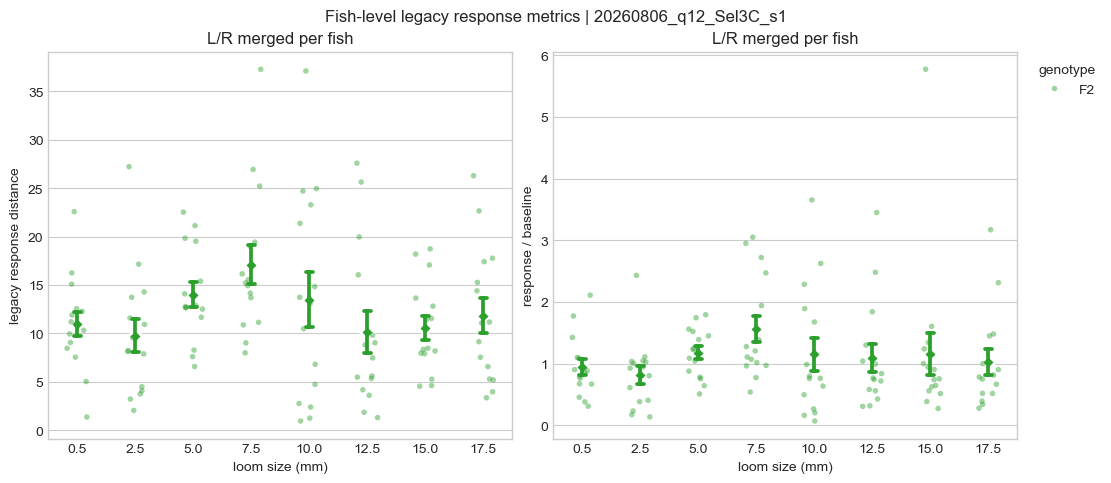

,loom_max_size,animal_id,genotype,response_dist,response_over_baseline,loom_size_mm,genotype_label
0,1,386.0,f2,11.907277,2.111046,0.5,F2
1,1,387.0,f2,16.255401,0.850867,0.5,F2
2,1,388.0,f2,15.092383,0.800521,0.5,F2
3,1,389.0,f2,11.209083,0.675007,0.5,F2
4,1,390.0,f2,10.325034,0.904007,0.5,F2
...,...,...,...,...,...,...,...
115,35,396.0,f2,11.179255,0.784335,17.5,F2
116,35,397.0,f2,17.776301,2.313054,17.5,F2
117,35,398.0,f2,3.976280,0.279661,17.5,F2
118,35,399.0,f2,5.289854,0.751314,17.5,F2


In [6]:
# Replace this value with any exact experiment name listed by the selection cell.
FISH_LEVEL_EXPERIMENT = '20260806_q12_Sel3C_s1'

# # Select trial-resolved fish metrics. L/R remain separate in this cached table.
# fish_trial_response = response_metrics.loc[
#     response_metrics['aggregation'].eq('animal_trial')
# ].copy()
# available_fish_experiments = sorted(fish_trial_response['experiment'].dropna().unique())
if FISH_LEVEL_EXPERIMENT not in available_fish_experiments:
    raise ValueError(
        f'FISH_LEVEL_EXPERIMENT must be one of {available_fish_experiments}; '
        f'got {FISH_LEVEL_EXPERIMENT!r}.'
    )

fish_trial_response = fish_trial_response.loc[
    fish_trial_response['experiment'].eq(FISH_LEVEL_EXPERIMENT)
].copy()
if SPLIT_PLOTS_BY_GENOTYPE:
    fish_trial_response = fish_trial_response.loc[
        fish_trial_response['genotype'].isin(ACTIVE_GENOTYPES)
    ].copy()
if fish_trial_response.empty:
    raise ValueError('No fish-level response rows remain after experiment and genotype filtering.')

# Average every same-size trial for each fish here, deliberately grouping over
# neither side nor trial so L/R are merged only at plotting time.
fish_response = fish_trial_response.groupby(
    ['loom_max_size', 'animal_id', 'genotype'], as_index=False, dropna=False
)[['response_dist', 'response_over_baseline']].mean()
fish_response['loom_size_mm'] = fish_response['loom_max_size'] / 2.0
fish_response['genotype_label'] = fish_response['genotype'].map(genotype_display)
fish_size_order = sorted(fish_response['loom_size_mm'].unique())

# Seaborn handles the fish distributions and mean +/- SEM summaries.
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)
fish_plot_metrics = [
    ('response_dist', 'legacy response distance'),
    ('response_over_baseline', 'response / baseline'),
]
for ax, (metric, ylabel) in zip(axes, fish_plot_metrics):
    metric_data = fish_response.loc[np.isfinite(fish_response[metric])].copy()
    shared_kwargs = {
        'data': metric_data, 'x': 'loom_size_mm', 'y': metric,
        'order': fish_size_order, 'ax': ax,
    }
    if SPLIT_PLOTS_BY_GENOTYPE:
        present_genotypes = [g for g in ACTIVE_GENOTYPES if g in set(metric_data['genotype'])]
        hue_order = [genotype_display(g) for g in present_genotypes]
        palette = {genotype_display(g): GENOTYPE_COLORS[g] for g in present_genotypes}
        hue_kwargs = {'hue': 'genotype_label', 'hue_order': hue_order, 'palette': palette}
        dodge_genotypes = len(present_genotypes) > 1
        sns.stripplot(
            **shared_kwargs, **hue_kwargs, dodge=dodge_genotypes, jitter=0.18,
            alpha=0.45, size=4, legend='auto' if ax is axes[-1] else False,
        )
        sns.pointplot(
            **shared_kwargs, **hue_kwargs, dodge=dodge_genotypes, estimator='mean',
            errorbar='se', markers='D', linestyles='none', capsize=0.12,
            markeredgecolor='white', legend=False,
        )
    else:
        sns.stripplot(
            **shared_kwargs, color='#3569b8', jitter=0.18, alpha=0.45, size=4,
        )
        sns.pointplot(
            **shared_kwargs, color='#3569b8', estimator='mean', errorbar='se',
            markers='D', linestyles='none', capsize=0.12, markeredgecolor='white',
        )
    ax.set_xlabel('loom size (mm)')
    ax.set_ylabel(ylabel)
    ax.set_title('L/R merged per fish')
if SPLIT_PLOTS_BY_GENOTYPE:
    axes[-1].legend(title='genotype', bbox_to_anchor=(1.02, 1), loc='upper left')
fig.suptitle(f'Fish-level legacy response metrics | {FISH_LEVEL_EXPERIMENT}', y=1.04)
plt.show()
display(fish_response.sort_values(['genotype', 'loom_max_size', 'animal_id']))

### Fish-level legacy response metrics across experiments

Select one `loom_max_size` below. Each point is the mean across fish in one experiment after repeated L/R trials are averaged per fish; error bars are the standard deviation across fish.

c:\Users\crodri19\AppData\Local\miniconda3\envs\jlsocial\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 5.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\crodri19\AppData\Local\miniconda3\envs\jlsocial\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 12.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\crodri19\AppData\Local\miniconda3\envs\jlsocial\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 8.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\crodri19\AppData\Local\miniconda3\envs\jlsocial\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 12.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.w

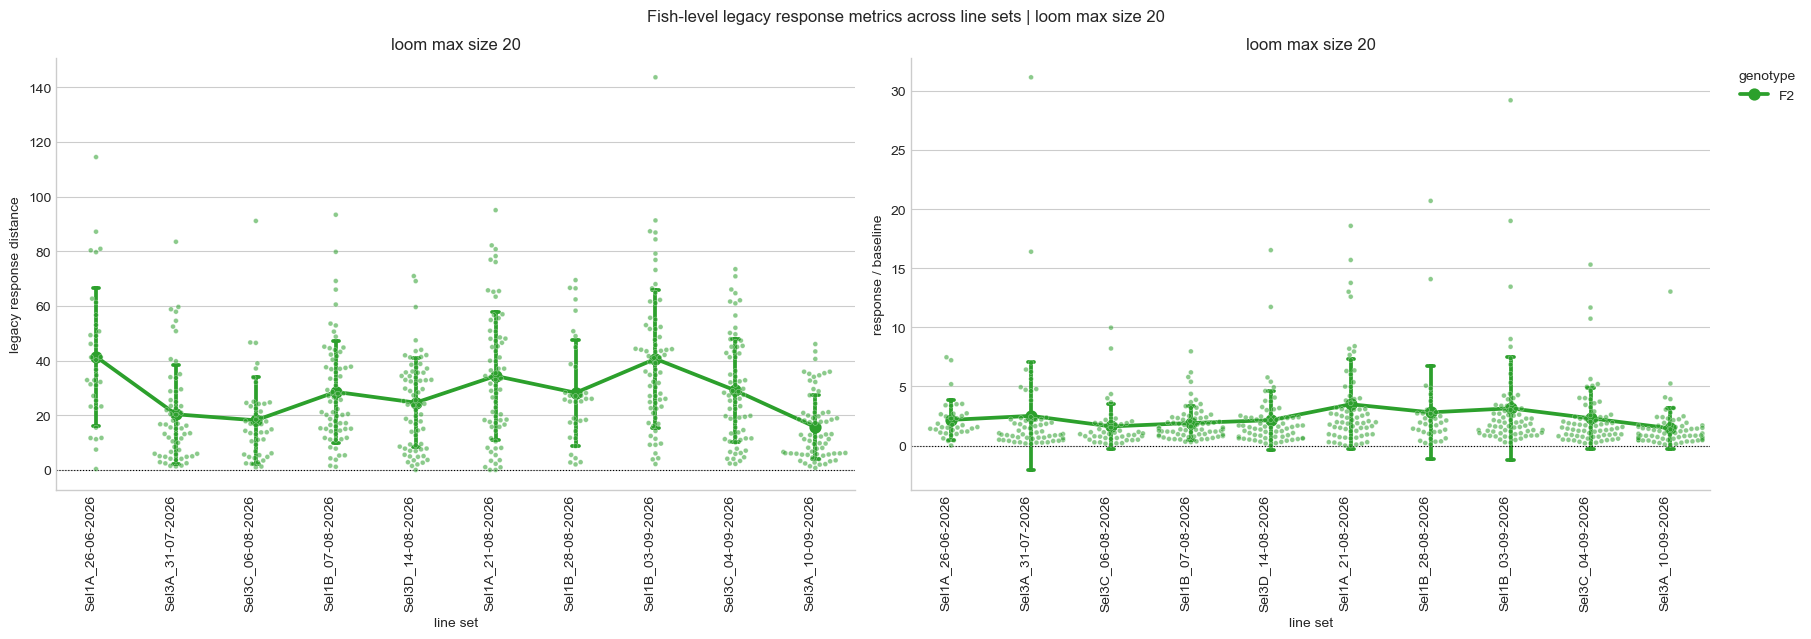

,experiment,loom_max_size,animal_id,genotype,response_dist,response_over_baseline,genotype_label,comparison_group
280,20260821_q18_Sel1A_s1,20,596.0,f2,18.187236,3.999085,F2,Sel1A_21-08-2026
281,20260821_q18_Sel1A_s1,20,597.0,f2,78.252234,1.979686,F2,Sel1A_21-08-2026
282,20260821_q18_Sel1A_s1,20,598.0,f2,26.523686,15.703007,F2,Sel1A_21-08-2026
283,20260821_q18_Sel1A_s1,20,599.0,f2,10.451598,0.667202,F2,Sel1A_21-08-2026
284,20260821_q18_Sel1A_s1,20,600.0,f2,8.074555,0.713414,F2,Sel1A_21-08-2026
...,...,...,...,...,...,...,...,...
275,20260814_q17_Sel3D_s2,20,591.0,f2,2.020691,0.172085,F2,Sel3D_14-08-2026
276,20260814_q17_Sel3D_s2,20,592.0,f2,47.423297,2.175976,F2,Sel3D_14-08-2026
277,20260814_q17_Sel3D_s2,20,593.0,f2,36.029731,0.841258,F2,Sel3D_14-08-2026
278,20260814_q17_Sel3D_s2,20,594.0,f2,35.593710,1.605290,F2,Sel3D_14-08-2026


In [7]:
# Edit this cached loom_max_size value to compare a different loom size.
EXPERIMENT_COMPARISON_LOOM_MAX_SIZE = 20
# Choose this plot's comparison level: 'experiment' or pooled 'line_set'.
EXPERIMENT_COMPARISON_GROUP_BY = 'line_set'
COMPARISON_GROUP_LABEL, EXPERIMENT_TO_COMPARISON_GROUP, COMPARISON_GROUP_ORDER = resolve_experiment_comparison_groups(
    experiments, EXPERIMENT_COMPARISON_GROUP_BY
)

# Keep fish-by-trial rows until repeated L/R trials are averaged for each fish.
experiment_trial_response = response_metrics.loc[
    response_metrics['aggregation'].eq('animal_trial')
].copy()
available_loom_max_sizes = sorted(experiment_trial_response['loom_max_size'].dropna().unique())
if EXPERIMENT_COMPARISON_LOOM_MAX_SIZE not in available_loom_max_sizes:
    raise ValueError(
        f'EXPERIMENT_COMPARISON_LOOM_MAX_SIZE must be one of '
        f'{available_loom_max_sizes}; got {EXPERIMENT_COMPARISON_LOOM_MAX_SIZE!r}.'
    )
experiment_trial_response = experiment_trial_response.loc[
    experiment_trial_response['loom_max_size'].eq(EXPERIMENT_COMPARISON_LOOM_MAX_SIZE)
].copy()
if SPLIT_PLOTS_BY_GENOTYPE:
    experiment_trial_response = experiment_trial_response.loc[
        experiment_trial_response['genotype'].isin(ACTIVE_GENOTYPES)
    ].copy()
if experiment_trial_response.empty:
    raise ValueError('No fish-level response rows remain after loom-size and genotype filtering.')

# Merge L/R and repeated trials downstream, retaining one mean response per fish.
experiment_fish_response = experiment_trial_response.groupby(
    ['experiment', 'loom_max_size', 'animal_id', 'genotype'],
    as_index=False,
    dropna=False,
)[['response_dist', 'response_over_baseline']].mean()
experiment_fish_response['genotype_label'] = experiment_fish_response['genotype'].map(genotype_display)
# In line-set mode, fish from all of a line set remain individual swarm points.
experiment_fish_response['comparison_group'] = experiment_fish_response['experiment'].astype(str).map(
    EXPERIMENT_TO_COMPARISON_GROUP
)
if experiment_fish_response['comparison_group'].isna().any():
    missing = sorted(experiment_fish_response.loc[experiment_fish_response['comparison_group'].isna(), 'experiment'].astype(str).unique())
    raise ValueError(f'No {COMPARISON_GROUP_LABEL} mapping for plotted experiments: {missing}')
available_groups = set(experiment_fish_response['comparison_group'].dropna())
comparison_group_order = [
    group for group in COMPARISON_GROUP_ORDER
    if group in available_groups
]
if not comparison_group_order:
    raise ValueError(f'No selected {COMPARISON_GROUP_LABEL} values contain fish-level rows for the requested loom size.')

# Match the slim shoaling-index point-plot style: group means, SD bars,
# genotype hues, and lines linking the ordered experiments.
fig, axes = plt.subplots(1, 2, figsize=(18, 6), constrained_layout=True)
experiment_plot_metrics = [
    ('response_dist', 'legacy response distance'),
    ('response_over_baseline', 'response / baseline'),
]
for ax, (metric, ylabel) in zip(axes, experiment_plot_metrics):
    metric_data = experiment_fish_response.loc[
        np.isfinite(experiment_fish_response[metric])
    ].copy()
    shared_kwargs = {
        'data': metric_data, 'x': 'comparison_group', 'y': metric,
        'order': comparison_group_order, 'ax': ax,
    }
    point_kwargs = {
        **shared_kwargs, 'estimator': 'mean', 'errorbar': 'sd',
        'linestyles': '-', 'markers': 'o', 'capsize': 0.08,
    }
    if SPLIT_PLOTS_BY_GENOTYPE:
        present_genotypes = [g for g in ACTIVE_GENOTYPES if g in set(metric_data['genotype'])]
        hue_order = [genotype_display(g) for g in present_genotypes]
        palette = {genotype_display(g): GENOTYPE_COLORS[g] for g in present_genotypes}
        hue_kwargs = {'hue': 'genotype_label', 'hue_order': hue_order, 'palette': palette}
        dodge_genotypes = len(present_genotypes) > 1
        sns.swarmplot(
            **shared_kwargs, **hue_kwargs, dodge=dodge_genotypes, size=3.5,
            alpha=0.55, edgecolor='white', linewidth=0.35, legend=False,
        )
        sns.pointplot(
            **point_kwargs, **hue_kwargs, dodge=dodge_genotypes,
            legend='auto' if ax is axes[-1] else False,
        )
    else:
        sns.swarmplot(
            **shared_kwargs, color='#3569b8', size=3.5, alpha=0.55,
            edgecolor='white', linewidth=0.35,
        )
        sns.pointplot(**point_kwargs, color='#3569b8')
    sns.despine(ax=ax)
    ax.axhline(0, ls=':', color='k', linewidth=0.8)
    ax.set_xlabel(COMPARISON_GROUP_LABEL)
    ax.set_ylabel(ylabel)
    ax.set_title(f'loom max size {EXPERIMENT_COMPARISON_LOOM_MAX_SIZE}')
    plt.setp(ax.get_xticklabels(), rotation=90, ha='right')
if SPLIT_PLOTS_BY_GENOTYPE:
    axes[-1].legend(title='genotype', bbox_to_anchor=(1.02, 1), loc='upper left')
fig.suptitle(
    f'Fish-level legacy response metrics across {COMPARISON_GROUP_LABEL}s | '
    f'loom max size {EXPERIMENT_COMPARISON_LOOM_MAX_SIZE}',
    y=1.04,
)
plt.show()
display(experiment_fish_response.sort_values(['comparison_group', 'experiment', 'genotype', 'animal_id']))

### Fish-level legacy response grid by line set

Each row is one metadata line set. Connected diamonds and error bars show the genotype mean +/- SEM across fish after repeated L/R trials are averaged per fish.

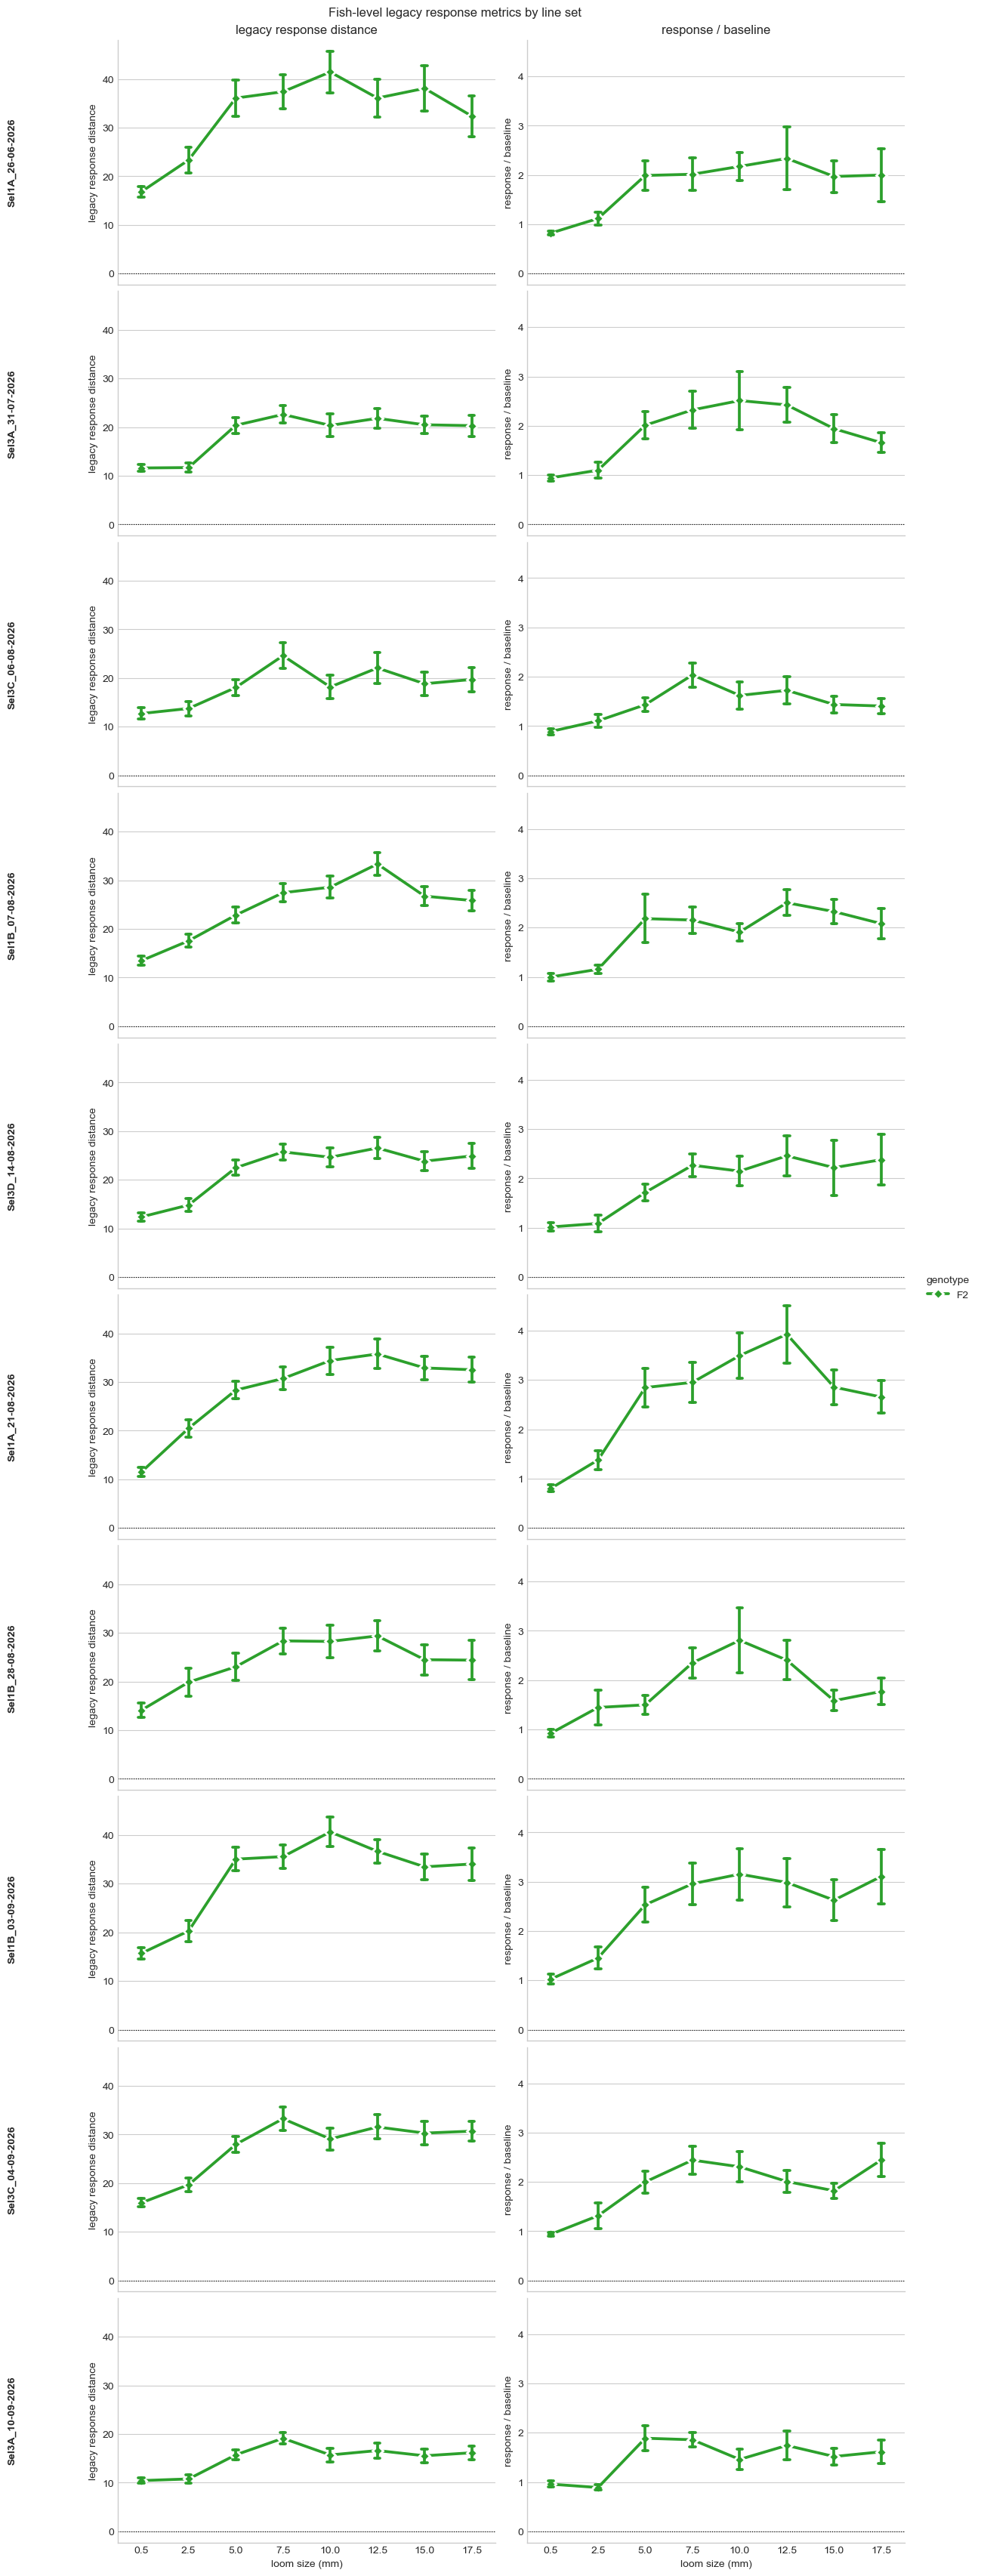

,experiment,loom_max_size,animal_id,genotype,response_dist,response_over_baseline,line_set,loom_size_mm,genotype_label
2240,20260821_q18_Sel1A_s1,1,596.0,f2,8.080703,1.737761,Sel1A_21-08-2026,0.5,F2
2241,20260821_q18_Sel1A_s1,1,597.0,f2,14.816684,0.552578,Sel1A_21-08-2026,0.5,F2
2242,20260821_q18_Sel1A_s1,1,598.0,f2,7.962531,0.265566,Sel1A_21-08-2026,0.5,F2
2243,20260821_q18_Sel1A_s1,1,599.0,f2,14.988369,1.059006,Sel1A_21-08-2026,0.5,F2
2244,20260821_q18_Sel1A_s1,1,600.0,f2,17.548079,3.269284,Sel1A_21-08-2026,0.5,F2
...,...,...,...,...,...,...,...,...,...
2235,20260814_q17_Sel3D_s2,35,591.0,f2,13.204170,1.137362,Sel3D_14-08-2026,17.5,F2
2236,20260814_q17_Sel3D_s2,35,592.0,f2,59.485110,2.144342,Sel3D_14-08-2026,17.5,F2
2237,20260814_q17_Sel3D_s2,35,593.0,f2,42.927872,1.881396,Sel3D_14-08-2026,17.5,F2
2238,20260814_q17_Sel3D_s2,35,594.0,f2,18.381591,2.068751,Sel3D_14-08-2026,17.5,F2


In [8]:
# Resolve every selected experiment to its single metadata line set.
_, EXPERIMENT_TO_GRID_LINE_SET, LINE_SET_GRID_ORDER = resolve_experiment_comparison_groups(
    experiments, 'line_set'
)

# Keep fish-by-trial rows until repeated trials and L/R sides are averaged.
line_set_trial_response = response_metrics.loc[
    response_metrics['aggregation'].eq('animal_trial')
].copy()
if SPLIT_PLOTS_BY_GENOTYPE:
    line_set_trial_response = line_set_trial_response.loc[
        line_set_trial_response['genotype'].isin(ACTIVE_GENOTYPES)
    ].copy()
if line_set_trial_response.empty:
    raise ValueError('No fish-level response rows remain for the line-set grid.')

# Retain experiment in the key so animal IDs cannot merge across recordings.
line_set_fish_response = line_set_trial_response.groupby(
    ['experiment', 'loom_max_size', 'animal_id', 'genotype'],
    as_index=False,
    dropna=False,
)[['response_dist', 'response_over_baseline']].mean()
line_set_fish_response['line_set'] = line_set_fish_response['experiment'].astype(str).map(
    EXPERIMENT_TO_GRID_LINE_SET
)
if line_set_fish_response['line_set'].isna().any():
    missing = sorted(
        line_set_fish_response.loc[
            line_set_fish_response['line_set'].isna(), 'experiment'
        ].astype(str).unique()
    )
    raise ValueError(f'No line set mapping for plotted experiments: {missing}')
line_set_fish_response['loom_size_mm'] = line_set_fish_response['loom_max_size'] / 2.0
line_set_fish_response['genotype_label'] = line_set_fish_response['genotype'].map(
    genotype_display
)

available_line_sets = set(line_set_fish_response['line_set'].dropna())
line_set_grid_order = [
    line_set for line_set in LINE_SET_GRID_ORDER
    if line_set in available_line_sets
]
if not line_set_grid_order:
    raise ValueError('No selected line sets contain fish-level legacy response rows.')
line_set_loom_size_order = sorted(line_set_fish_response['loom_size_mm'].dropna().unique())
line_set_grid_metrics = [
    ('response_dist', 'legacy response distance'),
    ('response_over_baseline', 'response / baseline'),
]

fig, axes = plt.subplots(
    len(line_set_grid_order),
    len(line_set_grid_metrics),
    figsize=(12, 3.4 * len(line_set_grid_order)),
    sharex='col',
    sharey='col',
    squeeze=False,
    constrained_layout=True,
)
for row_index, line_set in enumerate(line_set_grid_order):
    row_data = line_set_fish_response.loc[
        line_set_fish_response['line_set'].eq(line_set)
    ].copy()
    for column_index, (metric, ylabel) in enumerate(line_set_grid_metrics):
        ax = axes[row_index, column_index]
        metric_data = row_data.loc[np.isfinite(row_data[metric])].copy()
        shared_kwargs = {
            'data': metric_data,
            'x': 'loom_size_mm',
            'y': metric,
            'order': line_set_loom_size_order,
            'ax': ax,
        }
        if SPLIT_PLOTS_BY_GENOTYPE:
            present_genotypes = [
                genotype for genotype in ACTIVE_GENOTYPES
                if genotype in set(metric_data['genotype'])
            ]
            hue_order = [genotype_display(genotype) for genotype in present_genotypes]
            palette = {
                genotype_display(genotype): GENOTYPE_COLORS[genotype]
                for genotype in present_genotypes
            }
            hue_kwargs = {
                'hue': 'genotype_label',
                'hue_order': hue_order,
                'palette': palette,
            }
            dodge_genotypes = len(present_genotypes) > 1
            show_legend = row_index == 0 and column_index == 0
            sns.pointplot(
                **shared_kwargs, **hue_kwargs, dodge=dodge_genotypes,
                estimator='mean', errorbar='se', markers='D', linestyles='-',
                capsize=0.12, markeredgecolor='white',
                legend='auto' if show_legend else False,
            )
        else:
            sns.pointplot(
                **shared_kwargs, color='#3569b8', estimator='mean', errorbar='se',
                markers='D', linestyles='-', capsize=0.12,
                markeredgecolor='white',
            )
        sns.despine(ax=ax)
        ax.axhline(0, ls=':', color='k', linewidth=0.8)
        ax.set_ylabel(ylabel)
        if row_index == 0:
            ax.set_title(ylabel)
        if row_index == len(line_set_grid_order) - 1:
            ax.set_xlabel('loom size (mm)')
        else:
            ax.set_xlabel('')
        if column_index == 0:
            ax.text(
                -0.28, 0.5, line_set, transform=ax.transAxes, rotation=90,
                va='center', ha='center', fontsize=10, fontweight='bold',
            )

if SPLIT_PLOTS_BY_GENOTYPE:
    legend_handles, legend_labels = axes[0, 0].get_legend_handles_labels()
    if axes[0, 0].get_legend() is not None:
        axes[0, 0].get_legend().remove()
    if legend_handles:
        fig.legend(
            legend_handles, legend_labels, title='genotype',
            bbox_to_anchor=(1.01, 0.5), loc='center left',
        )
fig.suptitle('Fish-level legacy response metrics by line set')
plt.show()
display(
    line_set_fish_response.sort_values(
        ['line_set', 'experiment', 'genotype', 'loom_max_size', 'animal_id']
    )
)

## 3. Trial max post-loom velocity vs time since experiment start

Each native point is one experiment×genotype×trial value: the median across the selected fish of each fish's maximum speed during the post-loom window. Pooled mode uses the exact all-fish median. The alternative point mode averages matching size/side/condition trials across experiments. Each displayed genotype is fit independently with an estimated-floor Gaussian peak that captures the initial rise and subsequent decline. The fitted peak and rate summaries are descriptive and follow the selected point mode; loom size and time are partly confounded by the protocol sequence.

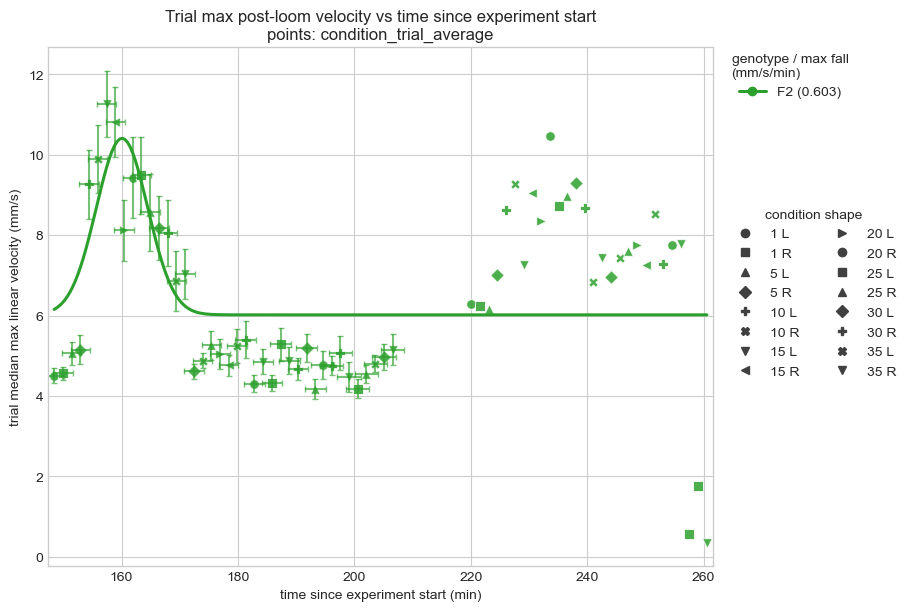

,genotype,fitted_floor_mm_s,amplitude_mm_s,peak_velocity_mm_s,peak_time_min,width_min,max_decrease_rate_mm_s_per_min,max_decrease_time_min,half_decay_time_min,r_squared,n_points,fit_status
0,f2,6.020161,4.392466,10.412627,160.083406,4.418757,0.602922,164.502163,5.202689,0.247454,68,ok


,loom_max_size,side,condition_trial,genotype,plot_x,plot_y,plot_x_sem,plot_y_sem,n_experiments,condition
0,1,L,1,f2,148.416667,4.508057,1.666667,0.193373,18,1 L
1,1,L,2,f2,182.818627,4.309819,1.764706,0.208042,17,1 L
2,1,L,3,f2,220.083333,6.294839,NaN,NaN,1,1 L
3,1,L,4,f2,254.583333,7.754031,NaN,NaN,1,1 L
4,1,R,1,f2,149.916667,4.564662,1.666667,0.166153,18,1 R
5,1,R,2,f2,185.818627,4.325443,1.764706,0.201265,17,1 R
6,1,R,3,f2,200.583333,4.183737,2.000000,0.232474,15,1 R
7,1,R,4,f2,221.583333,6.250000,NaN,NaN,1,1 R
8,1,R,5,f2,257.583333,0.559017,NaN,NaN,1,1 R
9,5,L,1,f2,151.416667,5.060156,1.666667,0.284472,18,5 L


In [9]:
# Configure point aggregation and discard small looms at or below the threshold.
TIME_POINT_MODE = 'condition_trial_average'  # 'experiments' or 'condition_trial_average'
MAX_LOOM_SIZE_EXCLUDE_THRESHOLD = 0
validate_point_mode(TIME_POINT_MODE)

# Select eligible trials and genotype groups; this is the source table for the plot.
time_source = trial_max_velocity.loc[
    trial_max_velocity['loom_max_size'].gt(MAX_LOOM_SIZE_EXCLUDE_THRESHOLD)
].copy()
time_source = select_plot_rows(time_source)
value_column = 'trial_median_max_linear_velocity_mm_s'
# Standardize both point modes to common plotting columns. In experiment mode
# each row is a point and SEM is undefined (NaN = "not a number").
if TIME_POINT_MODE == 'experiments':
    time_points = time_source.copy()
    time_points['plot_x'] = time_points['time_since_experiment_start_min']
    time_points['plot_y'] = time_points[value_column]
    time_points['plot_x_sem'] = np.nan
    time_points['plot_y_sem'] = np.nan
    time_points['n_experiments'] = 1
else:
    # In average mode, group corresponding condition trials across experiments,
    # then rename generated mean/SEM columns to generic plotting names.
    time_points = loom.summarize_across_experiments(
        time_source,
        plot_group_columns(['loom_max_size', 'side', 'condition_trial']),
        ['time_since_experiment_start_min', value_column],
    ).rename(columns={
        'time_since_experiment_start_min_mean': 'plot_x',
        'time_since_experiment_start_min_sem': 'plot_x_sem',
        f'{value_column}_mean': 'plot_y',
        f'{value_column}_sem': 'plot_y_sem',
    })
# Combine loom size and side into a readable condition label, and assign a
# distinct marker shape to every unique condition.
time_points['condition'] = time_points['loom_max_size'].astype(int).astype(str) + ' ' + time_points['side'].astype(str)
conditions = time_points[['loom_max_size', 'side', 'condition']].drop_duplicates().sort_values(['loom_max_size', 'side'])
condition_marker_symbols = ['o', 's', '^', 'D', 'P', 'X', 'v', '<', '>']
CONDITION_MARKERS = {
    condition: condition_marker_symbols[index % len(condition_marker_symbols)]
    for index, condition in enumerate(conditions['condition'])
}
# Import nonlinear least-squares fitting only where it is needed.
from scipy.optimize import curve_fit

# Gaussian peak model: a baseline (`floor`) plus a bell-shaped response.
# `amplitude` is height above baseline, `peak_elapsed_time` locates the peak,
# and `width` controls how quickly the curve rises and falls.
def gaussian_peak(elapsed_time, floor, amplitude, peak_elapsed_time, width):
    return floor + amplitude * np.exp(-0.5 * ((elapsed_time - peak_elapsed_time) / width) ** 2)

# First draw all observations. Colour identifies genotype and marker shape
# identifies loom condition; averages also receive horizontal and vertical SEM bars.
fig, ax = plt.subplots(figsize=(9, 6), constrained_layout=True)
plot_genotypes = ACTIVE_GENOTYPES if SPLIT_PLOTS_BY_GENOTYPE else [loom.POOLED_GENOTYPE]
for condition in conditions['condition']:
    for genotype in plot_genotypes:
        subset = time_points.loc[time_points['condition'].eq(condition) & time_points['genotype'].eq(genotype)]
        if subset.empty:
            continue
        point_color = GENOTYPE_COLORS[genotype] if SPLIT_PLOTS_BY_GENOTYPE else '0.25'
        ax.scatter(subset['plot_x'], subset['plot_y'], color=point_color, marker=CONDITION_MARKERS[condition], s=48, alpha=0.85, edgecolor='white', linewidth=0.7)
        # Averaged points have two uncertainty bars: horizontal = ± one SEM of
        # time across experiments; vertical = ± one SEM of velocity across experiments.
        # Raw experiment points have no error bars because each point is one experiment.
        if TIME_POINT_MODE == 'condition_trial_average':
            ax.errorbar(subset['plot_x'], subset['plot_y'], xerr=subset['plot_x_sem'], yerr=subset['plot_y_sem'], fmt='none', ecolor=point_color, alpha=0.65, capsize=2)
# Remove infinite/missing times before fitting and use the earliest time as zero.
finite_time = time_points['plot_x'].replace([np.inf, -np.inf], np.nan).dropna()
fit_time_origin = finite_time.min() if not finite_time.empty else np.nan
# Collect one diagnostic/result dictionary for each genotype.
fit_rows = []
for genotype in plot_genotypes:
    # Keep only finite x/y values for this genotype and sort them by time.
    fit_data = (
        time_points.loc[time_points['genotype'].eq(genotype), ['plot_x', 'plot_y']]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .sort_values('plot_x')
    )
    # Pre-fill all output fields with NaN/status values so failed and successful
    # fits produce the same table structure.
    fit_result = {
        'genotype': genotype,
        'fitted_floor_mm_s': np.nan,
        'amplitude_mm_s': np.nan,
        'peak_velocity_mm_s': np.nan,
        'peak_time_min': np.nan,
        'width_min': np.nan,
        'max_decrease_rate_mm_s_per_min': np.nan,
        'max_decrease_time_min': np.nan,
        'half_decay_time_min': np.nan,
        'r_squared': np.nan,
        'n_points': len(fit_data),
        'fit_status': 'not fitted',
    }
    # Require enough observations and actual time variation before attempting a fit.
    if len(fit_data) < 5:
        fit_result['fit_status'] = 'insufficient finite points (need at least 5)'
    elif fit_data['plot_x'].nunique() < 2:
        fit_result['fit_status'] = 'no time variation'
    else:
        # Shift absolute minutes to elapsed time, estimate data scales, and choose
        # plausible starting values and lower/upper bounds for the optimizer.
        elapsed_time = fit_data['plot_x'].to_numpy(dtype=float) - fit_time_origin
        velocity = fit_data['plot_y'].to_numpy(dtype=float)
        time_span = float(np.ptp(elapsed_time))
        velocity_scale = max(float(np.nanmax(velocity)), np.finfo(float).eps)
        initial_floor = np.clip(float(np.nanmin(velocity)) * 0.8, 0, velocity_scale * 0.95)
        initial_amplitude = max(float(np.nanmax(velocity)) - initial_floor, np.finfo(float).eps)
        initial_peak_time = float(elapsed_time[np.nanargmax(velocity)])
        minimum_width = min(0.5, time_span)
        maximum_width = max(time_span * 2, minimum_width + np.finfo(float).eps)
        initial_width = np.clip(time_span / 6, minimum_width, maximum_width)
        # Curve fitting can legitimately fail for noisy/sparse data, so catch expected
        # numerical errors and record them instead of stopping the notebook.
        try:
            # Fit the four Gaussian parameters. `maxfev` allows extra optimizer evaluations;
            # the second returned value (parameter covariance) is intentionally unused.
            parameters, _ = curve_fit(
                gaussian_peak,
                elapsed_time,
                velocity,
                p0=(initial_floor, initial_amplitude, initial_peak_time, initial_width),
                bounds=((0, 0, 0, minimum_width), (velocity_scale, np.inf, time_span, maximum_width)),
                maxfev=50000,
            )
            fitted_floor, amplitude, peak_elapsed_time, width = parameters
            fitted_velocity = gaussian_peak(elapsed_time, *parameters)
            # R² compares unexplained squared error with total variation. Values nearer 1
            # indicate that the fitted curve follows the observed points more closely.
            residual_sum_squares = np.sum((velocity - fitted_velocity) ** 2)
            total_sum_squares = np.sum((velocity - velocity.mean()) ** 2)
            r_squared = 1 - residual_sum_squares / total_sum_squares if total_sum_squares > 0 else np.nan
            peak_time = fit_time_origin + peak_elapsed_time
            # Derive biologically useful quantities from the Gaussian: peak time/velocity,
            # steepest falling rate, its time, and the post-peak half-height decay time.
            max_decrease_rate = amplitude * np.exp(-0.5) / width
            half_decay_time = width * np.sqrt(2 * np.log(2))
            fit_result.update({
                'fitted_floor_mm_s': fitted_floor,
                'amplitude_mm_s': amplitude,
                'peak_velocity_mm_s': fitted_floor + amplitude,
                'peak_time_min': peak_time,
                'width_min': width,
                'max_decrease_rate_mm_s_per_min': max_decrease_rate,
                'max_decrease_time_min': peak_time + width,
                'half_decay_time_min': half_decay_time,
                'r_squared': r_squared,
                'fit_status': 'ok',
            })
            # Evaluate the fitted model on 250 evenly spaced times to draw a smooth curve.
            fit_x = np.linspace(fit_data['plot_x'].min(), fit_data['plot_x'].max(), 250)
            fit_color = GENOTYPE_COLORS[genotype] if SPLIT_PLOTS_BY_GENOTYPE else '0.25'
            # This is the single best-fitting Gaussian curve. No confidence or
            # prediction interval is drawn around the fitted line.
            ax.plot(fit_x, gaussian_peak(fit_x - fit_time_origin, *parameters), color=fit_color, lw=2.2, zorder=2)
        except (RuntimeError, ValueError, FloatingPointError) as error:
            fit_result['fit_status'] = f'fit failed: {error}'
    fit_rows.append(fit_result)
# Convert collected dictionaries to a DataFrame and warn about skipped fits.
fit_summary = pd.DataFrame(fit_rows)
for row in fit_rows:
    if row['fit_status'] != 'ok':
        print(f"WARNING: Gaussian peak velocity fit for {genotype_display(row['genotype'])} skipped ({row['fit_status']}).")
ax.set_xlabel('time since experiment start (min)')
ax.set_ylabel('trial median max linear velocity (mm/s)')
ax.set_title(f'Trial max post-loom velocity vs time since experiment start\npoints: {TIME_POINT_MODE}')
# Construct legend entries that state the maximum fall rate when a fit exists.
genotype_handles = []
for genotype in plot_genotypes:
    row = fit_summary.loc[fit_summary['genotype'].eq(genotype)].iloc[0]
    fit_available = row['fit_status'] == 'ok'
    label = genotype_display(genotype)
    if fit_available:
        label += f" ({row['max_decrease_rate_mm_s_per_min']:.3g})"
    else:
        label += ' (fit unavailable)'
    color = GENOTYPE_COLORS[genotype] if SPLIT_PLOTS_BY_GENOTYPE else '0.25'
    genotype_handles.append(plt.Line2D([], [], marker='o', color=color, linestyle='-' if fit_available else 'None', lw=2.2, label=label))
# A separate legend explains marker shapes without duplicating every combination.
condition_handles = [
    plt.Line2D([], [], marker=CONDITION_MARKERS[c], color='0.25', linestyle='None', label=c)
    for c in conditions['condition']
]
genotype_legend = ax.legend(handles=genotype_handles, title='genotype / max fall\n(mm/s/min)', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
ax.add_artist(genotype_legend)
ax.legend(handles=condition_handles, title='condition shape', bbox_to_anchor=(1.02, 0.70), loc='upper left', borderaxespad=0, ncol=2)
# Pad the time limits, render the plot, and display fit diagnostics plus source points.
if not finite_time.empty:
    ax.set_xlim(finite_time.min() - 1, finite_time.max() + 1)
plt.show()
display(fit_summary)
display(time_points.sort_values(['genotype', 'loom_max_size', 'side', 'condition_trial']).head(30))

## 4. Trial max post-loom velocity by loom side

The first layout resolves loom size within side; the second pools sizes within side. The switch controls whether boxes and dots use experiment×trial values or cross-experiment aligned-trial averages.

### Fish-level post-loom maximum velocity across experiments

Select one `loom_max_size` below. Each swarm point is one fish after its L/R and repeated trials are averaged; point-plot error bars show the standard deviation across fish within an experiment.

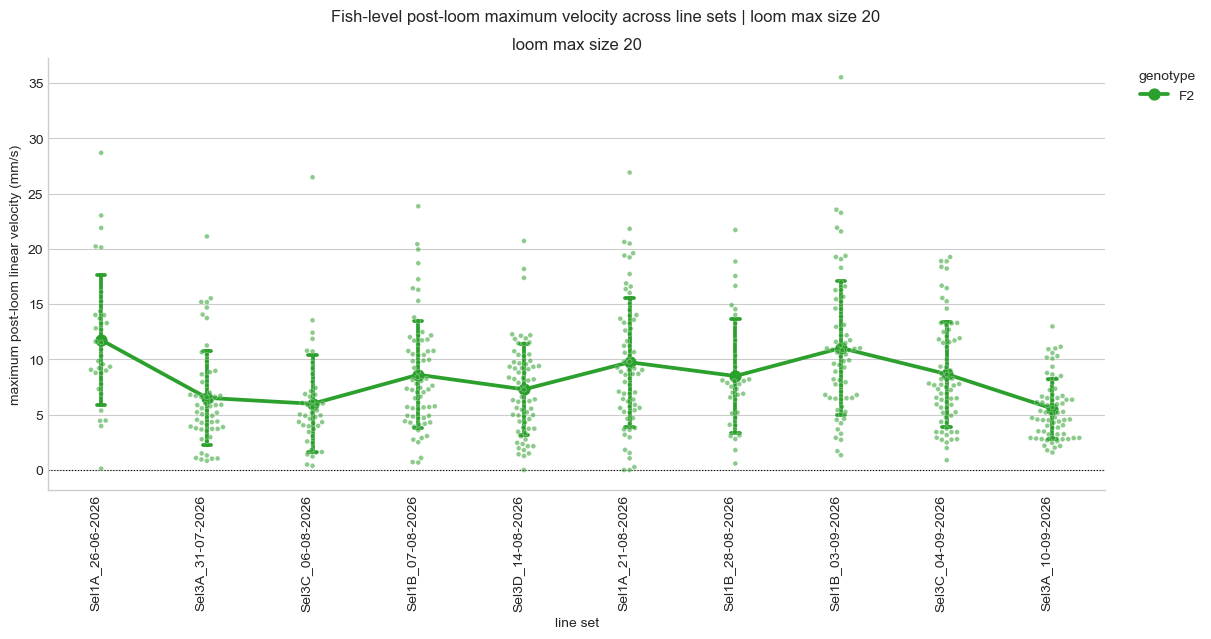

,experiment,loom_max_size,animal_id,genotype,fish_max_linear_velocity_mm_s,genotype_label,comparison_group
280,20260821_q18_Sel1A_s1,20,596,f2,5.399707,F2,Sel1A_21-08-2026
281,20260821_q18_Sel1A_s1,20,597,f2,19.610194,F2,Sel1A_21-08-2026
282,20260821_q18_Sel1A_s1,20,598,f2,6.900468,F2,Sel1A_21-08-2026
283,20260821_q18_Sel1A_s1,20,599,f2,3.669261,F2,Sel1A_21-08-2026
284,20260821_q18_Sel1A_s1,20,600,f2,3.182117,F2,Sel1A_21-08-2026
...,...,...,...,...,...,...,...
275,20260814_q17_Sel3D_s2,20,591,f2,1.495260,F2,Sel3D_14-08-2026
276,20260814_q17_Sel3D_s2,20,592,f2,12.271084,F2,Sel3D_14-08-2026
277,20260814_q17_Sel3D_s2,20,593,f2,11.443699,F2,Sel3D_14-08-2026
278,20260814_q17_Sel3D_s2,20,594,f2,9.750440,F2,Sel3D_14-08-2026


In [10]:
# Edit this cached loom_max_size value to compare a different loom size.
EXPERIMENT_MAX_VELOCITY_LOOM_MAX_SIZE = 20
# Choose this plot's comparison level: 'experiment' or pooled 'line_set'.
EXPERIMENT_COMPARISON_GROUP_BY = 'line_set'
COMPARISON_GROUP_LABEL, EXPERIMENT_TO_COMPARISON_GROUP, COMPARISON_GROUP_ORDER = resolve_experiment_comparison_groups(
    experiments, EXPERIMENT_COMPARISON_GROUP_BY
)

# Keep fish-by-trial maxima until repeated L/R trials are averaged for each fish.
experiment_max_velocity_trials = fish_trial_max_velocity.copy()
available_max_velocity_loom_sizes = sorted(
    experiment_max_velocity_trials['loom_max_size'].dropna().unique()
)
if EXPERIMENT_MAX_VELOCITY_LOOM_MAX_SIZE not in available_max_velocity_loom_sizes:
    raise ValueError(
        f'EXPERIMENT_MAX_VELOCITY_LOOM_MAX_SIZE must be one of '
        f'{available_max_velocity_loom_sizes}; '
        f'got {EXPERIMENT_MAX_VELOCITY_LOOM_MAX_SIZE!r}.'
    )
experiment_max_velocity_trials = experiment_max_velocity_trials.loc[
    experiment_max_velocity_trials['loom_max_size'].eq(
        EXPERIMENT_MAX_VELOCITY_LOOM_MAX_SIZE
    )
].copy()
if SPLIT_PLOTS_BY_GENOTYPE:
    experiment_max_velocity_trials = experiment_max_velocity_trials.loc[
        experiment_max_velocity_trials['genotype'].isin(ACTIVE_GENOTYPES)
    ].copy()
if experiment_max_velocity_trials.empty:
    raise ValueError('No fish-level maximum-velocity rows remain after loom-size and genotype filtering.')

# Merge L/R and repeated trials downstream, retaining one maximum-velocity mean per fish.
experiment_fish_max_velocity = experiment_max_velocity_trials.groupby(
    ['experiment', 'loom_max_size', 'animal_id', 'genotype'],
    as_index=False,
    dropna=False,
)[['fish_max_linear_velocity_mm_s']].mean()
experiment_fish_max_velocity['genotype_label'] = experiment_fish_max_velocity['genotype'].map(
    genotype_display
)
# In line-set mode, fish from all of a line set remain individual swarm points.
experiment_fish_max_velocity['comparison_group'] = experiment_fish_max_velocity['experiment'].astype(str).map(
    EXPERIMENT_TO_COMPARISON_GROUP
)
if experiment_fish_max_velocity['comparison_group'].isna().any():
    missing = sorted(experiment_fish_max_velocity.loc[experiment_fish_max_velocity['comparison_group'].isna(), 'experiment'].astype(str).unique())
    raise ValueError(f'No {COMPARISON_GROUP_LABEL} mapping for plotted experiments: {missing}')
available_groups = set(experiment_fish_max_velocity['comparison_group'].dropna())
comparison_group_order = [
    group for group in COMPARISON_GROUP_ORDER
    if group in available_groups
]
if not comparison_group_order:
    raise ValueError(f'No selected {COMPARISON_GROUP_LABEL} values contain fish-level rows for the requested loom size.')

# Match the fish-level response plot: swarms expose fish averages while the
# point plot shows group means, SD bars, and genotype-specific lines.
max_velocity_plot_data = experiment_fish_max_velocity.loc[
    np.isfinite(experiment_fish_max_velocity['fish_max_linear_velocity_mm_s'])
].copy()
fig, ax = plt.subplots(figsize=(12, 6), constrained_layout=True)
shared_kwargs = {
    'data': max_velocity_plot_data,
    'x': 'comparison_group',
    'y': 'fish_max_linear_velocity_mm_s',
    'order': comparison_group_order,
    'ax': ax,
}
point_kwargs = {
    **shared_kwargs,
    'estimator': 'mean',
    'errorbar': 'sd',
    'linestyles': '-',
    'markers': 'o',
    'capsize': 0.08,
}
if SPLIT_PLOTS_BY_GENOTYPE:
    present_genotypes = [
        genotype for genotype in ACTIVE_GENOTYPES
        if genotype in set(max_velocity_plot_data['genotype'])
    ]
    hue_order = [genotype_display(genotype) for genotype in present_genotypes]
    palette = {
        genotype_display(genotype): GENOTYPE_COLORS[genotype]
        for genotype in present_genotypes
    }
    hue_kwargs = {'hue': 'genotype_label', 'hue_order': hue_order, 'palette': palette}
    dodge_genotypes = len(present_genotypes) > 1
    sns.swarmplot(
        **shared_kwargs,
        **hue_kwargs,
        dodge=dodge_genotypes,
        size=3.5,
        alpha=0.55,
        edgecolor='white',
        linewidth=0.35,
        legend=False,
    )
    sns.pointplot(
        **point_kwargs,
        **hue_kwargs,
        dodge=dodge_genotypes,
        legend='auto',
    )
else:
    sns.swarmplot(
        **shared_kwargs,
        color='#3569b8',
        size=3.5,
        alpha=0.55,
        edgecolor='white',
        linewidth=0.35,
    )
    sns.pointplot(**point_kwargs, color='#3569b8')
sns.despine(ax=ax)
ax.axhline(0, ls=':', color='k', linewidth=0.8)
ax.set_xlabel(COMPARISON_GROUP_LABEL)
ax.set_ylabel('maximum post-loom linear velocity (mm/s)')
ax.set_title(f'loom max size {EXPERIMENT_MAX_VELOCITY_LOOM_MAX_SIZE}')
plt.setp(ax.get_xticklabels(), rotation=90, ha='right')
if SPLIT_PLOTS_BY_GENOTYPE:
    ax.legend(title='genotype', bbox_to_anchor=(1.02, 1), loc='upper left')
fig.suptitle(
    f'Fish-level post-loom maximum velocity across {COMPARISON_GROUP_LABEL}s | '
    f'loom max size {EXPERIMENT_MAX_VELOCITY_LOOM_MAX_SIZE}',
    y=1.04,
)
plt.show()
display(
    experiment_fish_max_velocity.sort_values(['comparison_group', 'experiment', 'genotype', 'animal_id'])
)

## 5. Unsided `CLsemi030` fish-level analyses

The last two experiments use an additional unsided size-30 stimulus that is intentionally separate from `CLsemi030L` and `CLsemi030R`. Their identical `QTLmap_35wp_MixShoalSimpleLoom30TuningLoom.csv` protocols contain one 54,000-frame `CLsemi030` block with five center-positioned (`stim_x = 0`, `stim_y = 0`) loom pulses. Pulse onsets occur at block frames 5,400, 16,200, 27,000, 37,800, and 48,600; each pulse has 21 positive-size frames and reaches size 30. In contrast, sided size-30 looms occupy separate 2,700-frame blocks at `stim_x = -20` or `+20`.

The cache extractor therefore splits the long unsided block at every zero-to-positive size transition. Existing sections load only L/R-labelled tables; this section uses the two dedicated unsided fish-by-trial tables. Each plotted fish value is its mean across the five unsided pulses in that experiment.

,experiment,n_unsided_pulses
0,20260731_q10_Sel3A_s1,5
1,20260731_q11_Sel3A_s2,5
2,20260806_q12_Sel3C_s1,5
3,20260806_q13_Sel3C_s2,5
4,20260807_q14_Sel1B_s1,5
5,20260807_q15_Sel1B_s2,5
6,20260814_q16_Sel3D_s1,5
7,20260814_q17_Sel3D_s2,5
8,20260821_q18_Sel1A_s1,5
9,20260821_q19_Sel1A_s2,5


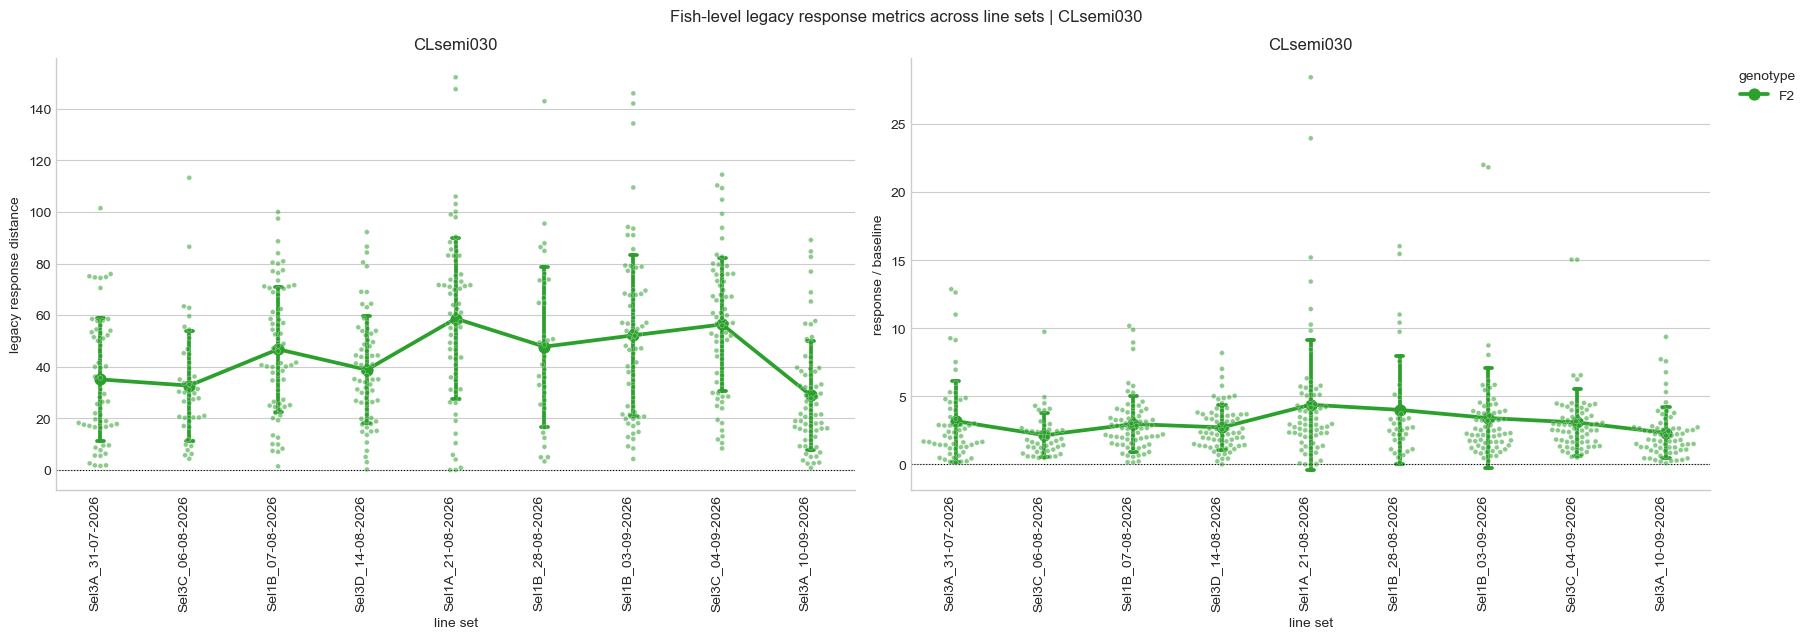

,experiment,animal_id,genotype,response_dist,response_over_baseline,genotype_label,comparison_group
245,20260821_q18_Sel1A_s1,596,f2,43.592993,5.095680,F2,Sel1A_21-08-2026
246,20260821_q18_Sel1A_s1,597,f2,152.192245,3.470572,F2,Sel1A_21-08-2026
247,20260821_q18_Sel1A_s1,598,f2,49.126077,8.433624,F2,Sel1A_21-08-2026
248,20260821_q18_Sel1A_s1,599,f2,56.386416,3.766210,F2,Sel1A_21-08-2026
249,20260821_q18_Sel1A_s1,600,f2,25.987306,1.237953,F2,Sel1A_21-08-2026
...,...,...,...,...,...,...,...
240,20260814_q17_Sel3D_s2,591,f2,18.809111,1.384825,F2,Sel3D_14-08-2026
241,20260814_q17_Sel3D_s2,592,f2,58.730768,3.590286,F2,Sel3D_14-08-2026
242,20260814_q17_Sel3D_s2,593,f2,40.608019,2.171761,F2,Sel3D_14-08-2026
243,20260814_q17_Sel3D_s2,594,f2,84.285311,3.665031,F2,Sel3D_14-08-2026


In [11]:
UNSIDED_LOOM_EPISODE = 'CLsemi030'
# Choose this plot's comparison level: 'experiment' or pooled 'line_set'.
UNSIDED_RESPONSE_COMPARISON_GROUP_BY = 'line_set'
UNSIDED_RESPONSE_GROUP_LABEL, UNSIDED_RESPONSE_GROUP_MAP, UNSIDED_RESPONSE_GROUP_ORDER = resolve_experiment_comparison_groups(
    experiments, UNSIDED_RESPONSE_COMPARISON_GROUP_BY
)

# Reuse the notebook's fish-level across-experiment visual grammar for the
# two unsided analyses below: fish swarms plus experiment means and SD bars.
def plot_unsided_fish_summary(data, metrics, comparison_group_order, comparison_group_label, title):
    fig, axes = plt.subplots(
        1, len(metrics), figsize=(9 * len(metrics), 6), constrained_layout=True
    )
    axes = np.atleast_1d(axes)
    for ax, (metric, ylabel) in zip(axes, metrics):
        metric_data = data.loc[np.isfinite(data[metric])].copy()
        shared_kwargs = {
            'data': metric_data, 'x': 'comparison_group', 'y': metric,
            'order': comparison_group_order, 'ax': ax,
        }
        point_kwargs = {
            **shared_kwargs, 'estimator': 'mean', 'errorbar': 'sd',
            'linestyles': '-', 'markers': 'o', 'capsize': 0.08,
        }
        if SPLIT_PLOTS_BY_GENOTYPE:
            present_genotypes = [
                genotype for genotype in ACTIVE_GENOTYPES
                if genotype in set(metric_data['genotype'])
            ]
            hue_order = [genotype_display(genotype) for genotype in present_genotypes]
            palette = {
                genotype_display(genotype): GENOTYPE_COLORS[genotype]
                for genotype in present_genotypes
            }
            hue_kwargs = {
                'hue': 'genotype_label', 'hue_order': hue_order, 'palette': palette,
            }
            dodge_genotypes = len(present_genotypes) > 1
            sns.swarmplot(
                **shared_kwargs, **hue_kwargs, dodge=dodge_genotypes, size=3.5,
                alpha=0.55, edgecolor='white', linewidth=0.35, legend=False,
            )
            sns.pointplot(
                **point_kwargs, **hue_kwargs, dodge=dodge_genotypes,
                legend='auto' if ax is axes[-1] else False,
            )
        else:
            sns.swarmplot(
                **shared_kwargs, color='#3569b8', size=3.5, alpha=0.55,
                edgecolor='white', linewidth=0.35,
            )
            sns.pointplot(**point_kwargs, color='#3569b8')
        sns.despine(ax=ax)
        ax.axhline(0, ls=':', color='k', linewidth=0.8)
        ax.set_xlabel(comparison_group_label)
        ax.set_ylabel(ylabel)
        ax.set_title(UNSIDED_LOOM_EPISODE)
        plt.setp(ax.get_xticklabels(), rotation=90, ha='right')
    if SPLIT_PLOTS_BY_GENOTYPE:
        axes[-1].legend(title='genotype', bbox_to_anchor=(1.02, 1), loc='upper left')
    fig.suptitle(title, y=1.04)
    plt.show()

unsided_trial_response = unsided_response_metrics.loc[
    unsided_response_metrics['episode'].eq(UNSIDED_LOOM_EPISODE)
    & unsided_response_metrics['aggregation'].eq('animal_trial')
].copy()
if SPLIT_PLOTS_BY_GENOTYPE:
    unsided_trial_response = unsided_trial_response.loc[
        unsided_trial_response['genotype'].isin(ACTIVE_GENOTYPES)
    ].copy()
if unsided_trial_response.empty:
    raise ValueError(f'No fish-level rows were extracted for {UNSIDED_LOOM_EPISODE}.')

unsided_response_trial_counts = (
    unsided_trial_response[['experiment', 'trial']].drop_duplicates()
    .groupby('experiment').size().rename('n_unsided_pulses').reset_index()
)
display(unsided_response_trial_counts)
unsided_fish_response = unsided_trial_response.groupby(
    ['experiment', 'animal_id', 'genotype'], as_index=False, dropna=False
)[['response_dist', 'response_over_baseline']].mean()
unsided_fish_response['genotype_label'] = unsided_fish_response['genotype'].map(
    genotype_display
)
unsided_fish_response['comparison_group'] = unsided_fish_response['experiment'].astype(str).map(
    UNSIDED_RESPONSE_GROUP_MAP
)
if unsided_fish_response['comparison_group'].isna().any():
    missing = sorted(unsided_fish_response.loc[unsided_fish_response['comparison_group'].isna(), 'experiment'].astype(str).unique())
    raise ValueError(f'No {UNSIDED_RESPONSE_GROUP_LABEL} mapping for plotted experiments: {missing}')
unsided_response_groups = set(unsided_fish_response['comparison_group'].dropna())
unsided_response_group_order = [
    group for group in UNSIDED_RESPONSE_GROUP_ORDER
    if group in unsided_response_groups
]
if not unsided_response_group_order:
    raise ValueError(f'No selected {UNSIDED_RESPONSE_GROUP_LABEL} values contain fish-level rows.')
plot_unsided_fish_summary(
    unsided_fish_response,
    [
        ('response_dist', 'legacy response distance'),
        ('response_over_baseline', 'response / baseline'),
    ],
    unsided_response_group_order,
    UNSIDED_RESPONSE_GROUP_LABEL,
    f'Fish-level legacy response metrics across {UNSIDED_RESPONSE_GROUP_LABEL}s | {UNSIDED_LOOM_EPISODE}',
)
display(unsided_fish_response.sort_values(['comparison_group', 'experiment', 'genotype', 'animal_id']))

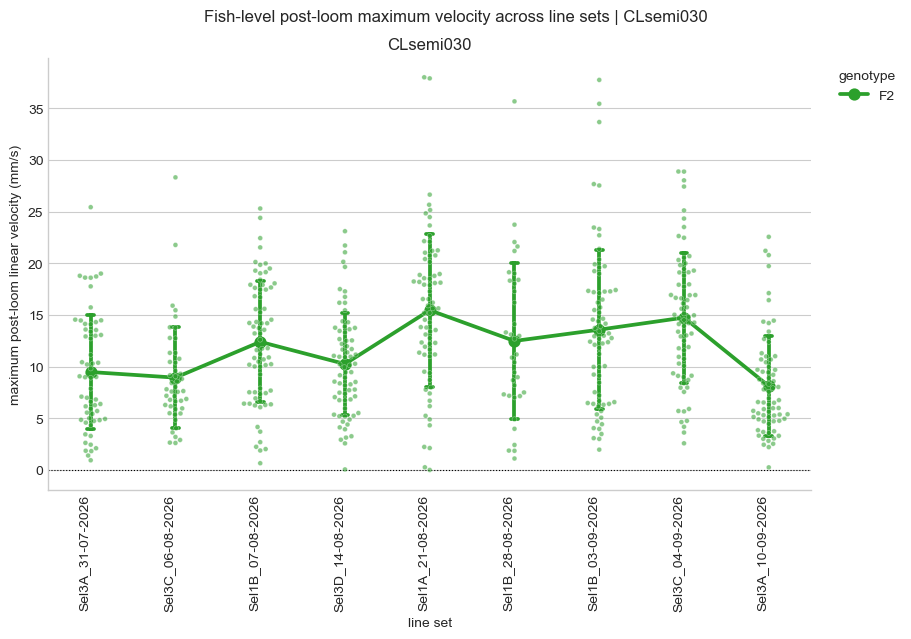

,experiment,animal_id,genotype,fish_max_linear_velocity_mm_s,genotype_label,comparison_group
245,20260821_q18_Sel1A_s1,596,f2,11.161402,F2,Sel1A_21-08-2026
246,20260821_q18_Sel1A_s1,597,f2,38.015622,F2,Sel1A_21-08-2026
247,20260821_q18_Sel1A_s1,598,f2,12.302230,F2,Sel1A_21-08-2026
248,20260821_q18_Sel1A_s1,599,f2,13.828786,F2,Sel1A_21-08-2026
249,20260821_q18_Sel1A_s1,600,f2,6.701269,F2,Sel1A_21-08-2026
...,...,...,...,...,...,...
240,20260814_q17_Sel3D_s2,591,f2,4.680363,F2,Sel3D_14-08-2026
241,20260814_q17_Sel3D_s2,592,f2,15.457548,F2,Sel3D_14-08-2026
242,20260814_q17_Sel3D_s2,593,f2,10.914727,F2,Sel3D_14-08-2026
243,20260814_q17_Sel3D_s2,594,f2,21.073128,F2,Sel3D_14-08-2026


In [12]:
# Choose this plot's comparison level: 'experiment' or pooled 'line_set'.
UNSIDED_MAX_VELOCITY_COMPARISON_GROUP_BY = 'line_set'
UNSIDED_MAX_VELOCITY_GROUP_LABEL, UNSIDED_MAX_VELOCITY_GROUP_MAP, UNSIDED_MAX_VELOCITY_GROUP_ORDER = resolve_experiment_comparison_groups(
    experiments, UNSIDED_MAX_VELOCITY_COMPARISON_GROUP_BY
)

unsided_max_velocity_trials = unsided_fish_trial_max_velocity.loc[
    unsided_fish_trial_max_velocity['episode'].eq(UNSIDED_LOOM_EPISODE)
].copy()
if SPLIT_PLOTS_BY_GENOTYPE:
    unsided_max_velocity_trials = unsided_max_velocity_trials.loc[
        unsided_max_velocity_trials['genotype'].isin(ACTIVE_GENOTYPES)
    ].copy()
if unsided_max_velocity_trials.empty:
    raise ValueError(
        f'No fish-level maximum-velocity rows were extracted for {UNSIDED_LOOM_EPISODE}.'
    )

unsided_fish_max_velocity = unsided_max_velocity_trials.groupby(
    ['experiment', 'animal_id', 'genotype'], as_index=False, dropna=False
)[['fish_max_linear_velocity_mm_s']].mean()
unsided_fish_max_velocity['genotype_label'] = unsided_fish_max_velocity['genotype'].map(
    genotype_display
)
unsided_fish_max_velocity['comparison_group'] = unsided_fish_max_velocity['experiment'].astype(str).map(
    UNSIDED_MAX_VELOCITY_GROUP_MAP
)
if unsided_fish_max_velocity['comparison_group'].isna().any():
    missing = sorted(unsided_fish_max_velocity.loc[unsided_fish_max_velocity['comparison_group'].isna(), 'experiment'].astype(str).unique())
    raise ValueError(f'No {UNSIDED_MAX_VELOCITY_GROUP_LABEL} mapping for plotted experiments: {missing}')
unsided_max_velocity_groups = set(unsided_fish_max_velocity['comparison_group'].dropna())
unsided_max_velocity_group_order = [
    group for group in UNSIDED_MAX_VELOCITY_GROUP_ORDER
    if group in unsided_max_velocity_groups
]
if not unsided_max_velocity_group_order:
    raise ValueError(f'No selected {UNSIDED_MAX_VELOCITY_GROUP_LABEL} values contain fish-level rows.')
plot_unsided_fish_summary(
    unsided_fish_max_velocity,
    [('fish_max_linear_velocity_mm_s', 'maximum post-loom linear velocity (mm/s)')],
    unsided_max_velocity_group_order,
    UNSIDED_MAX_VELOCITY_GROUP_LABEL,
    f'Fish-level post-loom maximum velocity across {UNSIDED_MAX_VELOCITY_GROUP_LABEL}s | {UNSIDED_LOOM_EPISODE}',
)
display(
    unsided_fish_max_velocity.sort_values(['comparison_group', 'experiment', 'genotype', 'animal_id'])
)

### Individual post-loom maximum velocity across the five unsided trials

Choose one experiment in the next cell. Each small point is one fish in one unsided trial; the connected point plot shows the trial mean +/- SEM across fish. Individual fish are not connected between trials.

In [13]:
# Identify which experiments contain the series of simple  unsided looms
available_unsided_trial_experiments = sorted(
    unsided_fish_trial_max_velocity.loc[
        unsided_fish_trial_max_velocity['episode'].eq(UNSIDED_LOOM_EPISODE),
        'experiment',
    ].dropna().unique()
)

available_unsided_trial_experiments

['20260731_q10_Sel3A_s1',
 '20260731_q11_Sel3A_s2',
 '20260806_q12_Sel3C_s1',
 '20260806_q13_Sel3C_s2',
 '20260807_q14_Sel1B_s1',
 '20260807_q15_Sel1B_s2',
 '20260814_q16_Sel3D_s1',
 '20260814_q17_Sel3D_s2',
 '20260821_q18_Sel1A_s1',
 '20260821_q19_Sel1A_s2',
 '20260828_q20_Sel1B_s1',
 '20260903_q21_Sel1B_s1',
 '20260903_q22_Sel1B_s2',
 '20260904_q23_Sel3C_s1',
 '20260904_q24_Sel3C_s2',
 '20260910_q25_Sel3A_s1',
 '20260910_q26_Sel3A_s2']

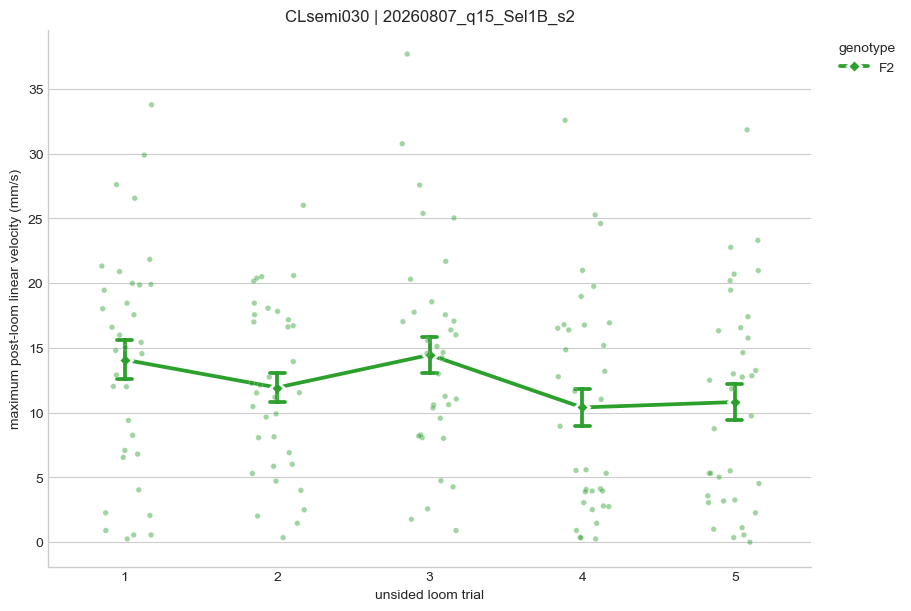

,experiment_index,experiment,trial,condition_trial,block,episode,side,loom_max_size,condition,fixed_loom_onset_frame,time_since_experiment_start_s,time_since_experiment_start_min,animal,fish_mean_pre_loom_linear_velocity_mm_s,fish_max_linear_velocity_mm_s,animal_id,genotype,txt_path,genotype_label
875,6,20260807_q15_Sel1B_s2,0,1,24,CLsemi030,NaN,30,30,221400,7380.0,123.0,1,3.396392,0.901388,491,f2,\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...,F2
876,6,20260807_q15_Sel1B_s2,0,1,24,CLsemi030,NaN,30,30,221400,7380.0,123.0,2,3.275633,14.800760,492,f2,\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...,F2
877,6,20260807_q15_Sel1B_s2,0,1,24,CLsemi030,NaN,30,30,221400,7380.0,123.0,3,1.170653,15.033296,493,f2,\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...,F2
878,6,20260807_q15_Sel1B_s2,0,1,24,CLsemi030,NaN,30,30,221400,7380.0,123.0,4,4.250626,14.553780,494,f2,\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...,F2
879,6,20260807_q15_Sel1B_s2,0,1,24,CLsemi030,NaN,30,30,221400,7380.0,123.0,5,2.094266,2.061553,495,f2,\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...,F2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1045,6,20260807_q15_Sel1B_s2,4,5,24,CLsemi030,NaN,30,30,264600,8820.0,147.0,31,10.005188,12.992786,521,f2,\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...,F2
1046,6,20260807_q15_Sel1B_s2,4,5,24,CLsemi030,NaN,30,30,264600,8820.0,147.0,32,3.093294,20.967236,522,f2,\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...,F2
1047,6,20260807_q15_Sel1B_s2,4,5,24,CLsemi030,NaN,30,30,264600,8820.0,147.0,33,3.083405,15.757935,523,f2,\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...,F2
1048,6,20260807_q15_Sel1B_s2,4,5,24,CLsemi030,NaN,30,30,264600,8820.0,147.0,34,5.074065,9.750000,524,f2,\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...,F2


['20260731_q10_Sel3A_s1',
 '20260731_q11_Sel3A_s2',
 '20260806_q12_Sel3C_s1',
 '20260806_q13_Sel3C_s2',
 '20260807_q14_Sel1B_s1',
 '20260807_q15_Sel1B_s2',
 '20260814_q16_Sel3D_s1',
 '20260814_q17_Sel3D_s2',
 '20260821_q18_Sel1A_s1',
 '20260821_q19_Sel1A_s2',
 '20260828_q20_Sel1B_s1',
 '20260903_q21_Sel1B_s1',
 '20260903_q22_Sel1B_s2',
 '20260904_q23_Sel3C_s1',
 '20260904_q24_Sel3C_s2',
 '20260910_q25_Sel3A_s1',
 '20260910_q26_Sel3A_s2']

In [14]:
# Replace this exact value with an experiment listed by available_unsided_trial_experiments.
UNSIDED_TRIAL_EXPERIMENT = '20260807_q15_Sel1B_s2'

# available_unsided_trial_experiments = sorted(
#     unsided_fish_trial_max_velocity.loc[
#         unsided_fish_trial_max_velocity['episode'].eq(UNSIDED_LOOM_EPISODE),
#         'experiment',
#     ].dropna().unique()
# )
if UNSIDED_TRIAL_EXPERIMENT not in available_unsided_trial_experiments:
    raise ValueError(
        f'UNSIDED_TRIAL_EXPERIMENT must be one of '
        f'{available_unsided_trial_experiments}; got {UNSIDED_TRIAL_EXPERIMENT!r}.'
    )
unsided_experiment_trials = unsided_fish_trial_max_velocity.loc[
    unsided_fish_trial_max_velocity['episode'].eq(UNSIDED_LOOM_EPISODE)
    & unsided_fish_trial_max_velocity['experiment'].eq(UNSIDED_TRIAL_EXPERIMENT)
].copy()
if SPLIT_PLOTS_BY_GENOTYPE:
    unsided_experiment_trials = unsided_experiment_trials.loc[
        unsided_experiment_trials['genotype'].isin(ACTIVE_GENOTYPES)
    ].copy()
if unsided_experiment_trials.empty:
    raise ValueError('No fish-level unsided trials remain after genotype filtering.')
unsided_experiment_trials['condition_trial'] = (
    unsided_experiment_trials['condition_trial'].astype(int)
)
unsided_experiment_trials['genotype_label'] = unsided_experiment_trials['genotype'].map(
    genotype_display
)
unsided_trial_order = sorted(unsided_experiment_trials['condition_trial'].unique())
if len(unsided_trial_order) != 5:
    print(
        f'WARNING: expected five unsided trials but found {len(unsided_trial_order)}: '
        f'{unsided_trial_order}'
    )

fig, ax = plt.subplots(figsize=(9, 6), constrained_layout=True)
trial_plot_kwargs = {
    'data': unsided_experiment_trials,
    'x': 'condition_trial',
    'y': 'fish_max_linear_velocity_mm_s',
    'order': unsided_trial_order,
    'ax': ax,
}
if SPLIT_PLOTS_BY_GENOTYPE:
    trial_genotypes = [
        genotype for genotype in ACTIVE_GENOTYPES
        if genotype in set(unsided_experiment_trials['genotype'])
    ]
    trial_hue_order = [genotype_display(genotype) for genotype in trial_genotypes]
    trial_palette = {
        genotype_display(genotype): GENOTYPE_COLORS[genotype]
        for genotype in trial_genotypes
    }
    trial_hue_kwargs = {
        'hue': 'genotype_label',
        'hue_order': trial_hue_order,
        'palette': trial_palette,
    }
    dodge_trials = len(trial_genotypes) > 1
    sns.stripplot(
        **trial_plot_kwargs, **trial_hue_kwargs, dodge=dodge_trials, jitter=0.18,
        alpha=0.45, size=4, edgecolor='white', linewidth=0.35, legend=False,
    )
    sns.pointplot(
        **trial_plot_kwargs, **trial_hue_kwargs, dodge=dodge_trials,
        estimator='mean', errorbar='se', markers='D', linestyles='-',
        capsize=0.10, markeredgecolor='white', legend='auto',
    )
    ax.legend(title='genotype', bbox_to_anchor=(1.02, 1), loc='upper left')
else:
    sns.stripplot(
        **trial_plot_kwargs, color='#3569b8', jitter=0.18, alpha=0.45,
        size=4, edgecolor='white', linewidth=0.35,
    )
    sns.pointplot(
        **trial_plot_kwargs, color='#3569b8', estimator='mean', errorbar='se',
        markers='D', linestyles='-', capsize=0.10, markeredgecolor='white',
    )
sns.despine(ax=ax)
ax.set_xlabel('unsided loom trial')
ax.set_ylabel('maximum post-loom linear velocity (mm/s)')
ax.set_title(f'{UNSIDED_LOOM_EPISODE} | {UNSIDED_TRIAL_EXPERIMENT}')
plt.show()
display(
    unsided_experiment_trials.sort_values(
        ['condition_trial', 'genotype', 'animal_id']
    )
)

available_unsided_trial_experiments

### Fish-level pre-loom average and post-loom maximum velocity

For each pulse, pre-loom speed is the mean of consecutive `VELOCITY_STEP_FRAMES` speed bins spanning the editable `PRE_VELOCITY_WINDOW_FRAMES` immediately before onset. The first figure overlays each fish's five-trial mean pre-loom speed and five-trial mean post-loom maximum. The second figure plots post divided by pre after those five-trial means are calculated; ratios with a zero or non-finite pre-loom mean are reported and excluded.

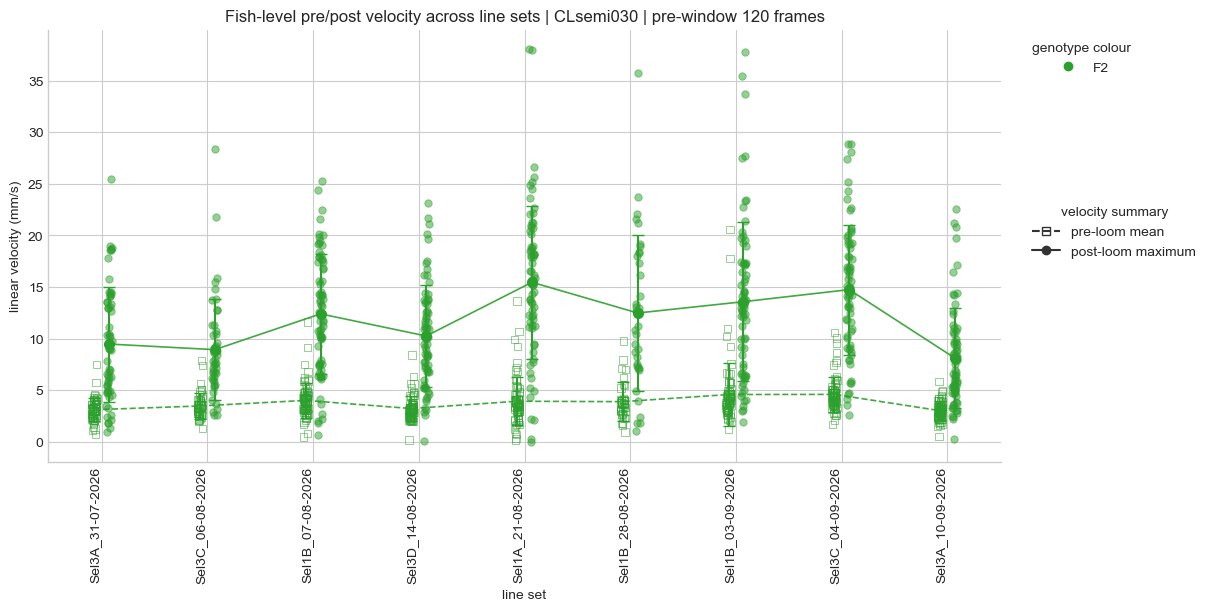

,experiment,n_fish_excluded_invalid_pre_velocity
0,20260731_q10_Sel3A_s1,0
1,20260731_q11_Sel3A_s2,0
2,20260806_q12_Sel3C_s1,0
3,20260806_q13_Sel3C_s2,0
4,20260807_q14_Sel1B_s1,0
5,20260807_q15_Sel1B_s2,0
6,20260814_q16_Sel3D_s1,0
7,20260814_q17_Sel3D_s2,0
8,20260821_q18_Sel1A_s1,0
9,20260821_q19_Sel1A_s2,0


c:\Users\crodri19\AppData\Local\miniconda3\envs\jlsocial\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 18.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\crodri19\AppData\Local\miniconda3\envs\jlsocial\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 8.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\crodri19\AppData\Local\miniconda3\envs\jlsocial\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 10.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\crodri19\AppData\Local\miniconda3\envs\jlsocial\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 5.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.w

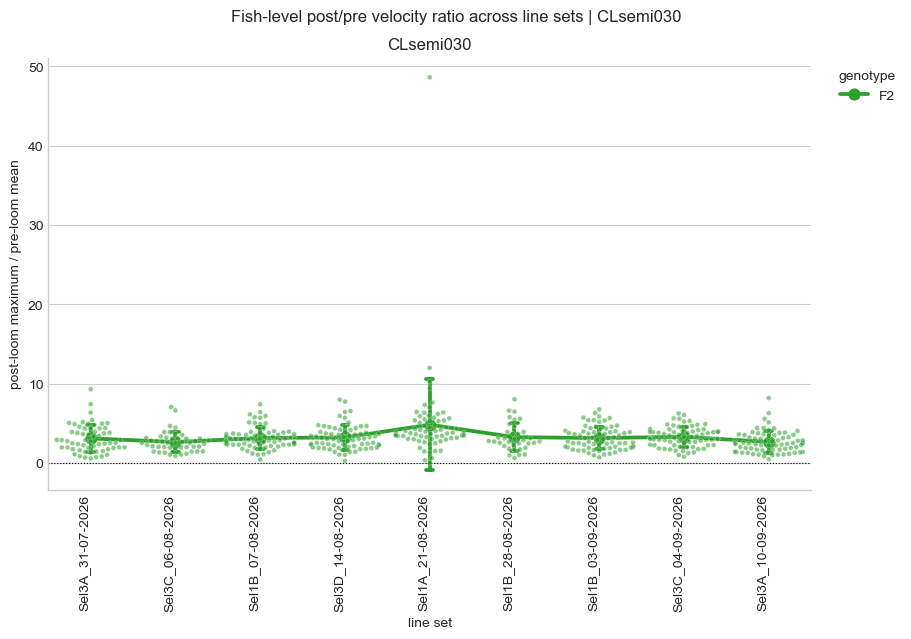

,experiment,animal_id,genotype,mean_pre_loom_velocity_mm_s,mean_post_loom_max_velocity_mm_s,n_pre_trials,n_post_trials,genotype_label,comparison_group,post_over_pre_velocity_ratio
245,20260821_q18_Sel1A_s1,596,f2,3.141883,11.161402,5,5,F2,Sel1A_21-08-2026,3.552456
246,20260821_q18_Sel1A_s1,597,f2,9.905149,38.015622,5,5,F2,Sel1A_21-08-2026,3.837966
247,20260821_q18_Sel1A_s1,598,f2,1.200013,12.302230,5,5,F2,Sel1A_21-08-2026,10.251745
248,20260821_q18_Sel1A_s1,599,f2,4.062066,13.828786,5,5,F2,Sel1A_21-08-2026,3.404373
249,20260821_q18_Sel1A_s1,600,f2,4.559836,6.701269,5,5,F2,Sel1A_21-08-2026,1.469630
...,...,...,...,...,...,...,...,...,...,...
240,20260814_q17_Sel3D_s2,591,f2,2.606620,4.680363,5,5,F2,Sel3D_14-08-2026,1.795568
241,20260814_q17_Sel3D_s2,592,f2,4.753049,15.457548,5,5,F2,Sel3D_14-08-2026,3.252133
242,20260814_q17_Sel3D_s2,593,f2,5.612475,10.914727,5,5,F2,Sel3D_14-08-2026,1.944726
243,20260814_q17_Sel3D_s2,594,f2,4.544057,21.073128,5,5,F2,Sel3D_14-08-2026,4.637514


In [15]:
PRE_VELOCITY_COLUMN = 'fish_mean_pre_loom_linear_velocity_mm_s'
POST_VELOCITY_COLUMN = 'fish_max_linear_velocity_mm_s'
# Choose this cell's comparison level: 'experiment' or pooled 'line_set'.
UNSIDED_PRE_POST_COMPARISON_GROUP_BY = 'line_set'
UNSIDED_PRE_POST_GROUP_LABEL, UNSIDED_PRE_POST_GROUP_MAP, UNSIDED_PRE_POST_GROUP_ORDER = resolve_experiment_comparison_groups(
    experiments, UNSIDED_PRE_POST_COMPARISON_GROUP_BY
)
if PRE_VELOCITY_COLUMN not in unsided_fish_trial_max_velocity:
    raise ValueError(
        'The loom cache predates pre-loom velocity extraction. Rerun the data-collection '
        'cell once to rebuild schema-version-7 caches.'
    )
unsided_pre_post_trials = unsided_fish_trial_max_velocity.loc[
    unsided_fish_trial_max_velocity['episode'].eq(UNSIDED_LOOM_EPISODE)
].copy()
if SPLIT_PLOTS_BY_GENOTYPE:
    unsided_pre_post_trials = unsided_pre_post_trials.loc[
        unsided_pre_post_trials['genotype'].isin(ACTIVE_GENOTYPES)
    ].copy()
if unsided_pre_post_trials.empty:
    raise ValueError('No unsided pre/post velocity rows remain after filtering.')

unsided_fish_pre_post = unsided_pre_post_trials.groupby(
    ['experiment', 'animal_id', 'genotype'], as_index=False, dropna=False
).agg(
    mean_pre_loom_velocity_mm_s=(PRE_VELOCITY_COLUMN, 'mean'),
    mean_post_loom_max_velocity_mm_s=(POST_VELOCITY_COLUMN, 'mean'),
    n_pre_trials=(PRE_VELOCITY_COLUMN, lambda values: int(np.isfinite(values).sum())),
    n_post_trials=(POST_VELOCITY_COLUMN, lambda values: int(np.isfinite(values).sum())),
)
complete_five_trial_mask = (
    unsided_fish_pre_post['n_pre_trials'].eq(5)
    & unsided_fish_pre_post['n_post_trials'].eq(5)
)
incomplete_velocity_counts = (
    unsided_fish_pre_post.loc[~complete_five_trial_mask]
    .groupby('experiment').size().rename('n_fish_excluded_incomplete_trials').reset_index()
)
if not incomplete_velocity_counts.empty:
    print('Fish excluded because fewer than five finite pre/post trials were available:')
    display(incomplete_velocity_counts)
unsided_fish_pre_post = unsided_fish_pre_post.loc[complete_five_trial_mask].copy()
if unsided_fish_pre_post.empty:
    raise ValueError('No fish have five finite pre- and post-loom velocity trials.')
unsided_fish_pre_post['genotype_label'] = unsided_fish_pre_post['genotype'].map(
    genotype_display
)
unsided_fish_pre_post['comparison_group'] = unsided_fish_pre_post['experiment'].astype(str).map(
    UNSIDED_PRE_POST_GROUP_MAP
)
if unsided_fish_pre_post['comparison_group'].isna().any():
    missing = sorted(unsided_fish_pre_post.loc[unsided_fish_pre_post['comparison_group'].isna(), 'experiment'].astype(str).unique())
    raise ValueError(f'No {UNSIDED_PRE_POST_GROUP_LABEL} mapping for plotted experiments: {missing}')
pre_post_groups = set(unsided_fish_pre_post['comparison_group'].dropna())
pre_post_group_order = [
    group for group in UNSIDED_PRE_POST_GROUP_ORDER
    if group in pre_post_groups
]
if not pre_post_group_order:
    raise ValueError(f'No selected {UNSIDED_PRE_POST_GROUP_LABEL} values contain fish-level rows.')

def plot_unsided_pre_post_overlay(data, comparison_group_order, comparison_group_label):
    fig, ax = plt.subplots(figsize=(12, 6), constrained_layout=True)
    x_base = np.arange(len(comparison_group_order), dtype=float)
    if SPLIT_PLOTS_BY_GENOTYPE:
        plot_genotypes = [
            genotype for genotype in ACTIVE_GENOTYPES
            if genotype in set(data['genotype'])
        ]
        plot_data = data.assign(plot_genotype=data['genotype'])
    else:
        plot_genotypes = [loom.POOLED_GENOTYPE]
        plot_data = data.assign(plot_genotype=loom.POOLED_GENOTYPE)
    genotype_offsets = (
        np.linspace(-0.18, 0.18, len(plot_genotypes))
        if len(plot_genotypes) > 1 else np.zeros(1)
    )
    periods = [
        ('pre', 'mean_pre_loom_velocity_mm_s', 's', '--', -0.07),
        ('post', 'mean_post_loom_max_velocity_mm_s', 'o', '-', 0.07),
    ]
    for genotype_index, genotype in enumerate(plot_genotypes):
        color = (
            GENOTYPE_COLORS[genotype]
            if SPLIT_PLOTS_BY_GENOTYPE else '#3569b8'
        )
        for period, metric, marker, linestyle, period_offset in periods:
            mean_positions = []
            mean_values = []
            for group_index, comparison_group in enumerate(comparison_group_order):
                subset = plot_data.loc[
                    plot_data['comparison_group'].eq(comparison_group)
                    & plot_data['plot_genotype'].eq(genotype)
                ]
                values = subset[metric].dropna().to_numpy(dtype=float)
                if len(values) == 0:
                    continue
                position = (
                    x_base[group_index]
                    + genotype_offsets[genotype_index]
                    + period_offset
                )
                facecolor = 'none' if period == 'pre' else color
                ax.scatter(
                    position + deterministic_jitter(len(values), 0.025), values,
                    marker=marker, facecolors=facecolor, edgecolors=color,
                    s=28, alpha=0.5, linewidths=0.7, zorder=2,
                )
                mean_value = float(np.mean(values))
                sd_value = float(np.std(values, ddof=1)) if len(values) > 1 else 0.0
                ax.errorbar(
                    position, mean_value, yerr=sd_value, color=color, marker=marker,
                    markerfacecolor=facecolor, markeredgecolor=color, linestyle='none',
                    capsize=4, ms=7, zorder=4,
                )
                mean_positions.append(position)
                mean_values.append(mean_value)
            if mean_positions:
                ax.plot(
                    mean_positions, mean_values, color=color, linestyle=linestyle,
                    linewidth=1.2, alpha=0.9, zorder=3,
                )
    period_handles = [
        plt.Line2D([], [], color='0.2', marker='s', markerfacecolor='none',
                   linestyle='--', label='pre-loom mean'),
        plt.Line2D([], [], color='0.2', marker='o', markerfacecolor='0.2',
                   linestyle='-', label='post-loom maximum'),
    ]
    if SPLIT_PLOTS_BY_GENOTYPE:
        genotype_handles = [
            plt.Line2D([], [], color=GENOTYPE_COLORS[genotype], marker='o',
                       linestyle='none', label=genotype_display(genotype))
            for genotype in plot_genotypes
        ]
        genotype_legend = ax.legend(
            handles=genotype_handles, title='genotype colour',
            bbox_to_anchor=(1.02, 1), loc='upper left',
        )
        ax.add_artist(genotype_legend)
    ax.legend(
        handles=period_handles, title='velocity summary',
        bbox_to_anchor=(1.02, 0.62 if SPLIT_PLOTS_BY_GENOTYPE else 1),
        loc='upper left',
    )
    ax.set_xticks(x_base)
    ax.set_xticklabels(comparison_group_order, rotation=90, ha='right')
    ax.set_xlabel(comparison_group_label)
    ax.set_ylabel('linear velocity (mm/s)')
    ax.set_title(
        f'Fish-level pre/post velocity across {comparison_group_label}s | {UNSIDED_LOOM_EPISODE} | '
        f'pre-window {PRE_VELOCITY_WINDOW_FRAMES} frames'
    )
    sns.despine(ax=ax)
    plt.show()

plot_unsided_pre_post_overlay(
    unsided_fish_pre_post, pre_post_group_order, UNSIDED_PRE_POST_GROUP_LABEL
)

valid_ratio_mask = (
    np.isfinite(unsided_fish_pre_post['mean_pre_loom_velocity_mm_s'])
    & unsided_fish_pre_post['mean_pre_loom_velocity_mm_s'].gt(0)
    & np.isfinite(unsided_fish_pre_post['mean_post_loom_max_velocity_mm_s'])
)
ratio_exclusions = (
    unsided_fish_pre_post.assign(excluded=~valid_ratio_mask)
    .groupby('experiment', as_index=False)['excluded'].sum()
    .rename(columns={'excluded': 'n_fish_excluded_invalid_pre_velocity'})
)
display(ratio_exclusions)
unsided_fish_velocity_ratio = unsided_fish_pre_post.loc[valid_ratio_mask].copy()
unsided_fish_velocity_ratio['post_over_pre_velocity_ratio'] = (
    unsided_fish_velocity_ratio['mean_post_loom_max_velocity_mm_s']
    / unsided_fish_velocity_ratio['mean_pre_loom_velocity_mm_s']
)
if unsided_fish_velocity_ratio.empty:
    raise ValueError('No finite post/pre velocity ratios remain for plotting.')
plot_unsided_fish_summary(
    unsided_fish_velocity_ratio,
    [('post_over_pre_velocity_ratio', 'post-loom maximum / pre-loom mean')],
    pre_post_group_order,
    UNSIDED_PRE_POST_GROUP_LABEL,
    f'Fish-level post/pre velocity ratio across {UNSIDED_PRE_POST_GROUP_LABEL}s | {UNSIDED_LOOM_EPISODE}',
)
display(
    unsided_fish_velocity_ratio.sort_values(
        ['comparison_group', 'experiment', 'genotype', 'animal_id']
    )
)